In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [1]:
# Đường dẫn tới tệp CSV
file_path = '/content/myInsight 2026_V2_Dataset.xlsx - Dataset.csv'

# Đọc tệp CSV
df = pd.read_csv(file_path)

# Hiển thị thông tin tổng quan và 5 dòng đầu tiên
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Columns: 1068 entries, Serial number to D7.Educational level
dtypes: int64(1), object(1067)
memory usage: 21.2+ MB
None


,Serial number,Wave,Region,D4.Income,D2.Gender,D3.Age,S2.Category used in P4W_Juice (freshly made),"S2.Category used in P4W_RTD Juice (can, bottle, tetra pak)",S2.Category used in P4W_Juice (powder),S2.Category used in P4W_Carbonated soft drink,...,Q_TP3_R27- Trà lá vối Seventy,Q_TP3_R2000- Trà thảo mộc VietFuji,Q_TP3_R3000- Trà sữa không độ/ Trà sữa Macchiato,Q_TP3_R5000- Trà TH True Tea,Q_TP3_R6000- Trà mật ong Boncha,Q_TP3_R7000- Trà Jokky,Q_TP3_R8000- Trà sữa C2,Q_TP3_R9000- Búp non 365,- D6.Occupation,D7.Educational level
0,"1,00",2025,South,"15,000,001 – 30,000,000 VND",Female,30 - 34 y.o.,No,No,No,No,...,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,5. White Collar (Managerial level and above),Studying/Graduated from university/college and...
1,"2,00",2025,South,"15,000,001 – 30,000,000 VND",Female,25 - 29 y.o.,Yes,Yes,No,Yes,...,#NULL!,#NULL!,#NULL!,#NULL!,When having meals/party with friends/family,#NULL!,#NULL!,#NULL!,6. White Collar (Junior level),Studying/Graduated from university/college and...
2,"3,00",2025,Mekong,"4,500,001 – 7,500,000 VND",Male,25 - 29 y.o.,No,Yes,No,Yes,...,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,11. Student/ Pupil,Studying/Graduated from university/college and...
3,"4,00",2025,South,"Above 45,000,001",Male,36 - 40 y.o.,Yes,No,Yes,Yes,...,#NULL!,#NULL!,#NULL!,When outside,#NULL!,#NULL!,#NULL!,When having meals/party with friends/family,5. White Collar (Managerial level and above),Studying/Graduated from university/college and...
4,"5,00",2025,South,"Above 45,000,001",Female,19 - 24 y.o.,No,No,No,Yes,...,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,#NULL!,When having meals/party with friends/family,6. White Collar (Junior level),Studying/Graduated from university/college and...


### Kiểm định Giả thuyết: Lỗ hổng Phễu thương hiệu (Brand Funnel Drop-off) cho Cozy
**Giả thuyết:** Khách hàng có cân nhắc Cozy nhưng tỷ lệ chuyển đổi sang hành vi mua thực tế (P4W) thấp.

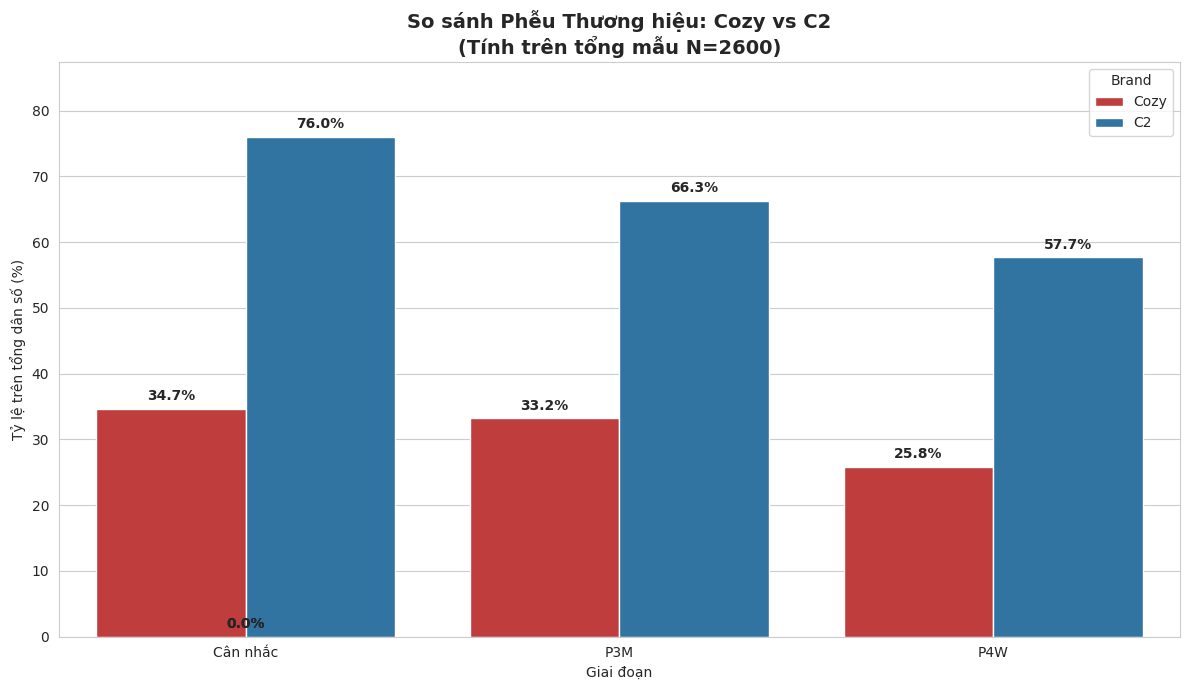

In [25]:
total_sample = 2600

# Chuẩn bị dữ liệu so sánh
comparison_data = [
    {'Brand': 'Cozy', 'Stage': 'Cân nhắc', 'Count': num_consider},
    {'Brand': 'Cozy', 'Stage': 'P3M', 'Count': num_p3m},
    {'Brand': 'Cozy', 'Stage': 'P4W', 'Count': num_p4w},
    {'Brand': 'C2', 'Stage': 'Cân nhắc', 'Count': num_consider_c2},
    {'Brand': 'C2', 'Stage': 'P3M', 'Count': num_p3m_c2},
    {'Brand': 'C2', 'Stage': 'P4W', 'Count': num_p4w_c2}
]

compare_df = pd.DataFrame(comparison_data)
compare_df['Rate_Total'] = (compare_df['Count'] / total_sample) * 100

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x='Stage', y='Rate_Total', hue='Brand', data=compare_df, palette=['#d62728', '#1f77b4'])

plt.title('So sánh Phễu Thương hiệu: Cozy vs C2\n(Tính trên tổng mẫu N=2600)', fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ trên tổng dân số (%)')
plt.xlabel('Giai đoạn')
plt.ylim(0, max(compare_df['Rate_Total']) * 1.15)

# Thêm nhãn số liệu
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

### Phân tích Độc lập: Độ phủ P3M vs P4W (Market Penetration)
Biểu đồ dưới đây so sánh tỷ lệ % người dùng đã sử dụng sản phẩm trong 3 tháng qua (P3M) và 4 tuần qua (P4W) tính trên tổng mẫu N=2600.

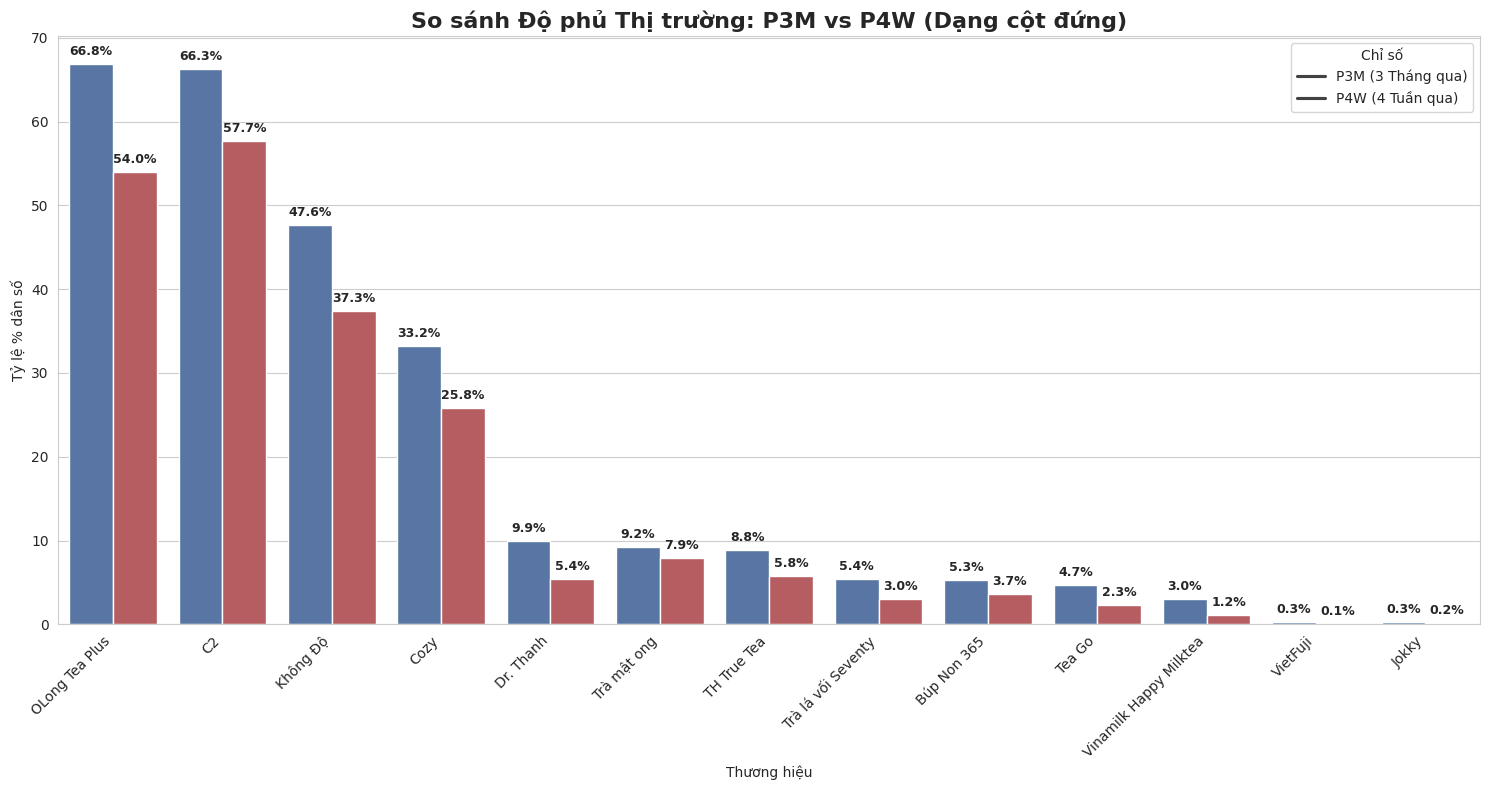

In [26]:
# Sử dụng cùng dữ liệu plot_data đã chuẩn bị ở trên
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Vẽ biểu đồ cột đứng (x='Brand', y='Rate')
ax = sns.barplot(x='Brand', y='Rate', hue='Metric', data=plot_data,
                 order=sort_order, palette=['#4c72b0', '#c44e52'])

plt.title('So sánh Độ phủ Thị trường: P3M vs P4W (Dạng cột đứng)', fontsize=16, fontweight='bold')
plt.ylabel('Tỷ lệ % dân số')
plt.xlabel('Thương hiệu')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chỉ số', labels=['P3M (3 Tháng qua)', 'P4W (4 Tuần qua)'])

# Thêm nhãn số liệu trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()

Top Rào cản đối với Trà Cozy (Tính trên N=2600):


,Barrier,Percentage,Count
0,Do not like the flavor/The flavor do not taste...,19.461538,506
5,Does not have enough flavour that I want to ch...,11.884615,309
10,Asked but the store does not sell it,5.461538,142
11,Not preserved in cool place,5.269231,137
3,Expensive than I expected,3.769231,98
6,Has higher sugar than I needed,3.269231,85
2,Do not trust in product quality,1.961538,51
7,Unpopular brands,1.615385,42
8,Do not like recent packaging designs,1.500000,39
1,Unhealthy,1.076923,28


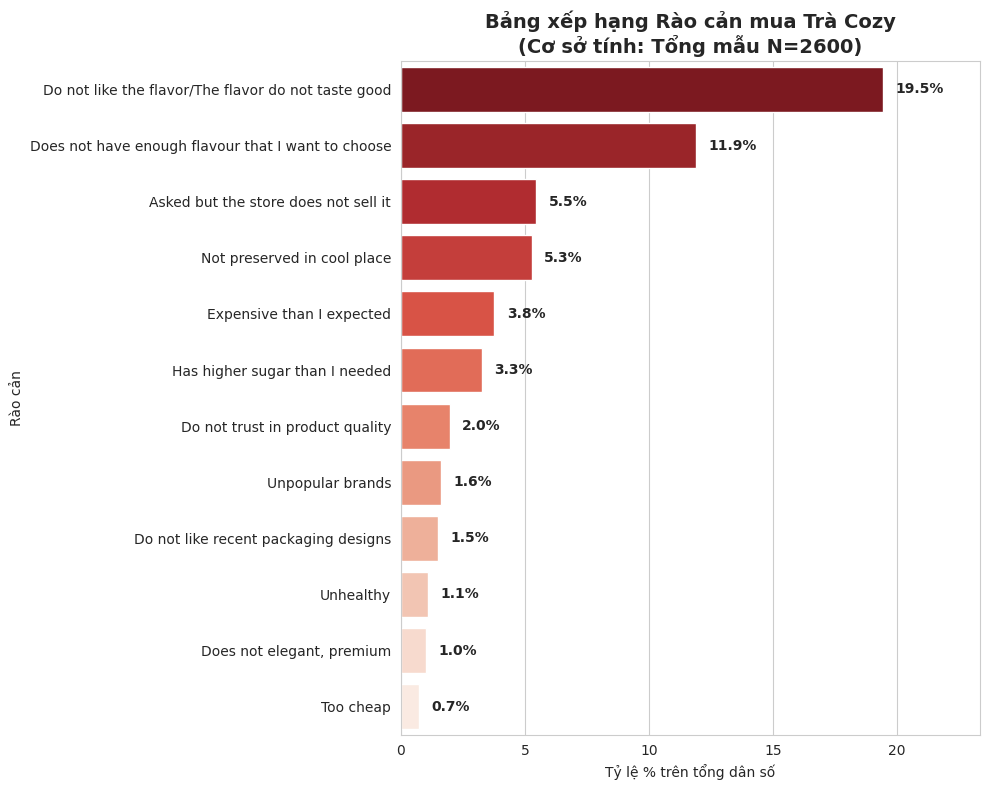

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bước 1: Tìm chính xác các cột rào cản
all_cozy_cols = [col for col in df.columns if 'Cozy' in col]
cozy_barrier_cols = [col for col in all_cozy_cols if 'ME' in col]

# Hằng số tổng mẫu
TOTAL_SAMPLE = 2600

if not cozy_barrier_cols:
    print("Không tìm thấy cột Q.ME.")
else:
    # Loại bỏ cột 'None' và 'Other'
    cozy_barrier_cols = [col for col in cozy_barrier_cols if 'none' not in col.lower() and 'other' not in col.lower()]

    barrier_results = []

    # Bước 2, 3, 4: Tính toán tỷ lệ % trên TỔNG MẪU (2600)
    for col in cozy_barrier_cols:
        clean_series = df[col].astype(str).str.strip().str.lower()

        # Đếm số người chọn 'Yes'
        num_yes = clean_series[clean_series.isin(['1', 'yes', 'selected', 'checked'])].count()

        # TÍNH TOÁN TRÊN TỔNG 2600
        percentage = (num_yes / TOTAL_SAMPLE) * 100

        # Lấy phần mô tả rào cản
        barrier_name = col.split('_')[-1] if '_' in col else col
        barrier_results.append({
            'Barrier': barrier_name,
            'Percentage': percentage,
            'Count': num_yes
        })

    if barrier_results:
        # Bước 5: Tạo DataFrame và Sắp xếp
        barriers_df = pd.DataFrame(barrier_results).sort_values('Percentage', ascending=False)

        # Bước 6: Hiển thị kết quả
        print(f"Top Rào cản đối với Trà Cozy (Tính trên N={TOTAL_SAMPLE}):")
        display(barriers_df.head(10))

        plt.figure(figsize=(10, 8))
        sns.barplot(x='Percentage', y='Barrier', data=barriers_df, palette='Reds_r', hue='Barrier', legend=False)
        plt.title(f'Bảng xếp hạng Rào cản mua Trà Cozy\n(Cơ sở tính: Tổng mẫu N={TOTAL_SAMPLE})', fontsize=14, fontweight='bold')
        plt.xlabel('Tỷ lệ % trên tổng dân số')
        plt.ylabel('Rào cản')
        plt.xlim(0, max(barriers_df['Percentage']) * 1.2)

        for i, v in enumerate(barriers_df['Percentage']):
            plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()
    else:
        print("Cảnh báo: Không có dữ liệu rào cản hợp lệ để hiển thị.")

### So sánh Rào cản mua hàng (Q.ME2): Cozy vs Đối thủ (C2, OLong Tea Plus, Không Độ)
Phân tích này giúp xác định xem các vấn đề về hương vị của Cozy là đặc thù của thương hiệu hay là xu hướng chung của ngành hàng.

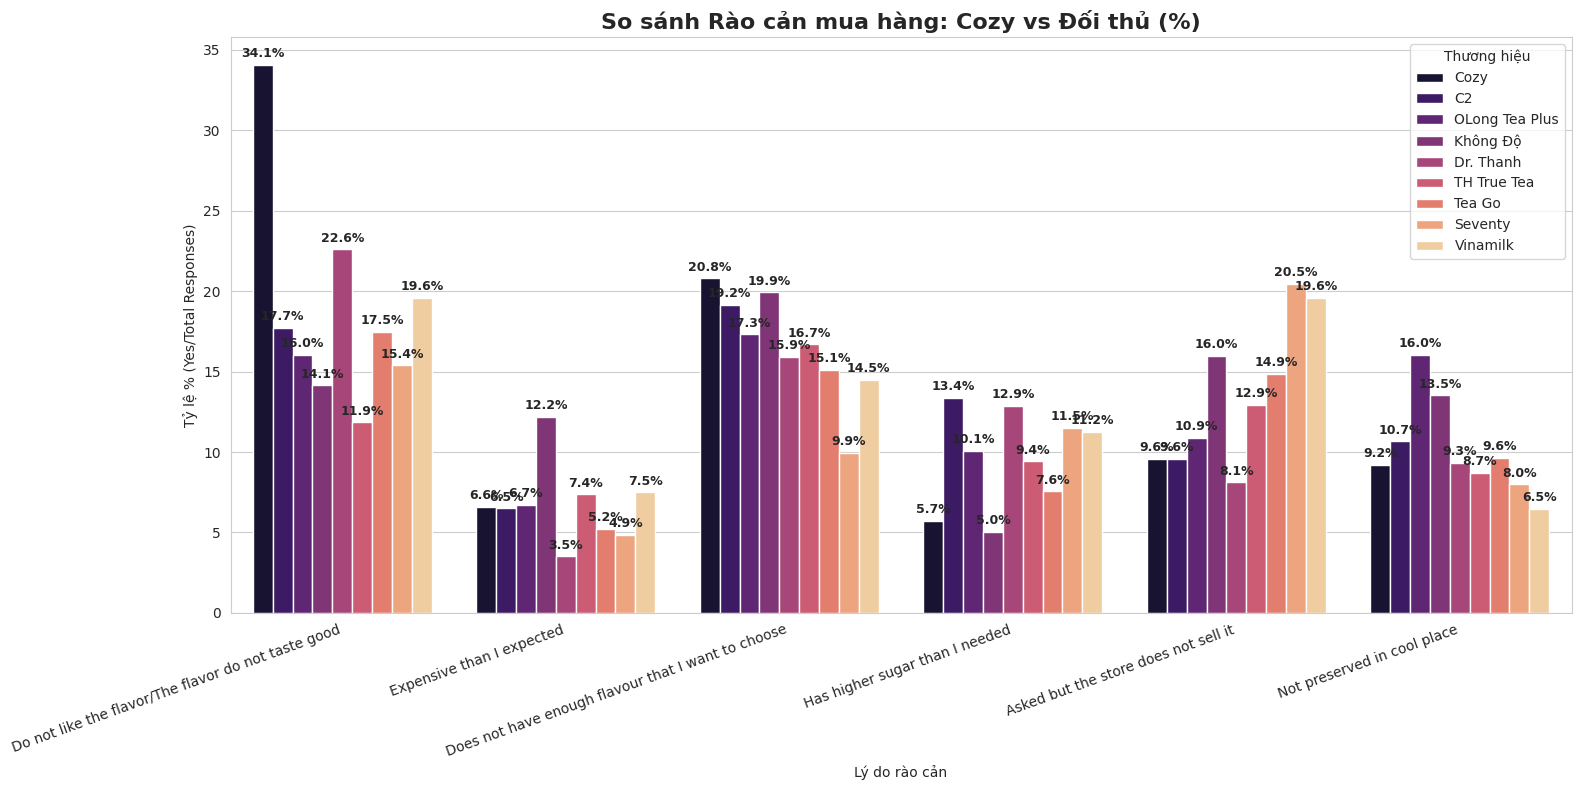

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Định nghĩa các thương hiệu và từ khóa tìm kiếm cột Q.ME2 tương ứng
comparison_brands = {
    'Cozy': 'Trà Cozy',
    'C2': 'C2',
    'OLong Tea Plus': 'OLong Tea Plus',
    'Không Độ': 'Không Độ',
    'Dr. Thanh': 'Dr. Thanh',
    'TH True Tea': 'TH True Tea',
    'Trà mật ong': 'mật ong',
    'Tea Go': 'Tea Go',
    'Seventy': 'Seventy',
    'Búp Non 365': '365',
    'Vinamilk': 'Vinamilk',
    'VietFuji': 'VietFuji',
    'Jokky': 'Jokky'
}

all_comparison_data = []

for brand_display, keyword in comparison_brands.items():
    # Tìm các cột rào cản của từng brand (QME2)
    brand_barrier_cols = [col for col in df.columns if 'QME2' in col and keyword in col]
    # Loại bỏ các cột 'None' hoặc 'Other' để tập trung vào rào cản chính
    brand_barrier_cols = [col for col in brand_barrier_cols if not any(x in col.lower() for x in ['none', 'other'])]

    for col in brand_barrier_cols:
        clean_series = df[col].astype(str).str.strip().str.lower()
        # Lọc bỏ giá trị rỗng/không hợp lệ
        clean_series = clean_series[~clean_series.isin(['nan', '#null!', '', 'none'])]

        # Tính số người chọn Yes (thường mã hóa là '1', 'yes', hoặc 'selected')
        num_yes = clean_series[clean_series.isin(['1', 'yes', 'selected', 'checked'])].count()
        total = clean_series.count()

        if total > 0:
            percentage = (num_yes / total) * 100
            # Lấy tên rào cản sau dấu gạch dưới
            barrier_name = col.split('_')[-1] if '_' in col else col

            all_comparison_data.append({
                'Brand': brand_display,
                'Barrier': barrier_name,
                'Percentage': percentage
            })

if all_comparison_data:
    comp_barriers_df = pd.DataFrame(all_comparison_data)

    # Lọc các nhóm rào cản quan trọng nhất để biểu đồ không bị quá dày
    target_keywords = ['flavor', 'flavour', 'Expensive', 'sell it', 'preserved', 'sugar']
    plot_comp_df = comp_barriers_df[comp_barriers_df['Barrier'].str.contains('|'.join(target_keywords), case=False)]

    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")

    ax = sns.barplot(x='Barrier', y='Percentage', hue='Brand', data=plot_comp_df, palette='magma')

    plt.title('So sánh Rào cản mua hàng: Cozy vs Đối thủ (%)', fontsize=16, fontweight='bold')
    plt.ylabel('Tỷ lệ % (Yes/Total Responses)')
    plt.xlabel('Lý do rào cản')
    plt.xticks(rotation=20, ha='right')
    plt.legend(title='Thương hiệu', bbox_to_anchor=(1, 1))

    # Thêm số liệu
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 8),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu rào cản cho các đối thủ. Vui lòng kiểm tra lại cấu trúc cột.")

### Phân tích Impact: Yếu tố nào ảnh hưởng mạnh nhất đến việc sụt giảm khách hàng?
Chúng ta sẽ tính chỉ số Impact bằng cách đo lường mối tương quan giữa từng rào cản và trạng thái **'Lapsed User'** (những người có P3M nhưng không có P4W). Chỉ số càng cao, yếu tố đó càng gây ra sự sụt giảm người dùng nghiêm trọng.

Consolidating P4W data from: ['Q4. P4W_Trà Cozy đóng chai', 'Q4. P4W_Trà Cozy Olong Xoài', 'Q4. P4W_Trà Cozy Vải', 'Q4. P4W_Trà Cozy Đào Sả']

--- Corrected Statistics ---
Total P3M Users: 863
Loyal Users (P4W): 671
Lapsed Users (Churned): 192


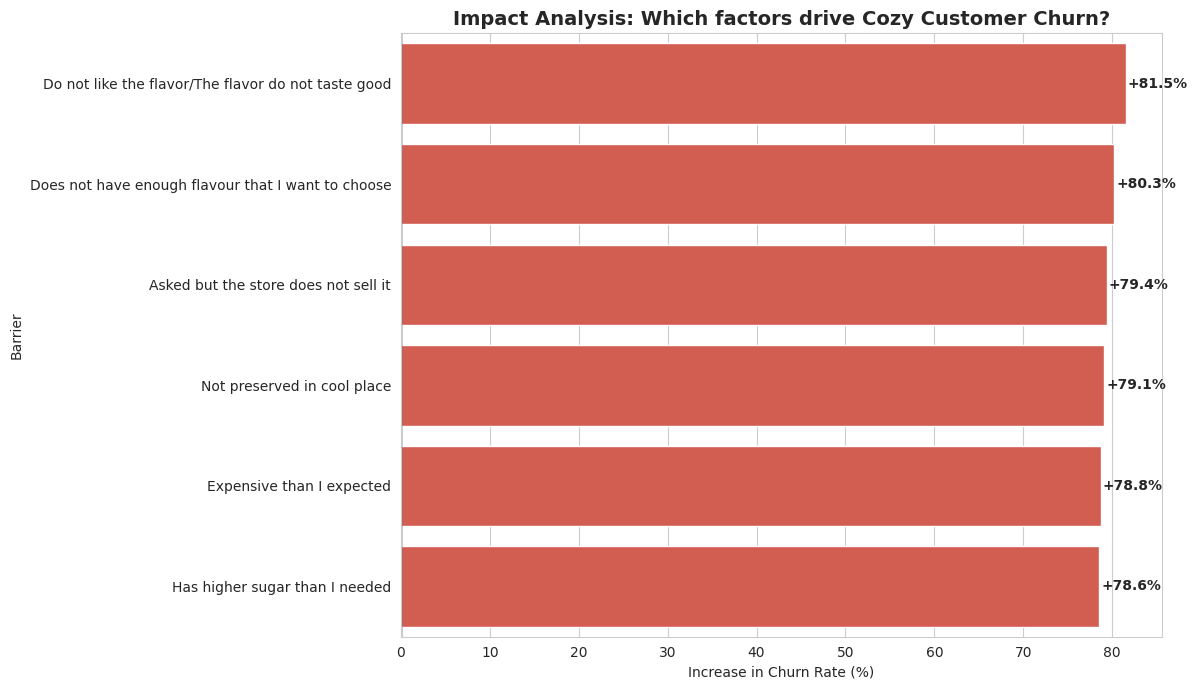

,Barrier,Impact_Score,Churn_Rate_With,Sample_Size
0,Do not like the flavor/The flavor do not taste...,81.530984,100.0,40
2,Does not have enough flavour that I want to ch...,80.263158,100.0,27
4,Asked but the store does not sell it,79.408284,100.0,18
5,Not preserved in cool place,79.127358,100.0,15
1,Expensive than I expected,78.755869,100.0,11
3,Has higher sugar than I needed,78.571429,100.0,9


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify all P4W sub-columns for Cozy
p3m_col = 'Q3. P3M _Trà Cozy đóng chai'
cozy_p4w_cols = [col for col in df.columns if 'Q4. P4W' in col and 'Cozy' in col]
print(f"Consolidating P4W data from: {cozy_p4w_cols}")

def is_yes(val):
    s = str(val).strip().lower()
    return s in ['1', 'yes', 'selected', 'checked']

# 2. Refined Logic: A user is Loyal if they appear in ANY Cozy P4W sub-column
cozy_p3m_users = df[df[p3m_col].apply(is_yes)].copy()

# Check across all sub-variants
cozy_p3m_users['Is_Loyal'] = df[cozy_p4w_cols].apply(lambda row: row.apply(is_yes).any(), axis=1)
cozy_p3m_users['Is_Lapsed'] = ~cozy_p3m_users['Is_Loyal']

print(f"\n--- Corrected Statistics ---")
print(f"Total P3M Users: {len(cozy_p3m_users)}")
print(f"Loyal Users (P4W): {cozy_p3m_users['Is_Loyal'].sum()}")
print(f"Lapsed Users (Churned): {cozy_p3m_users['Is_Lapsed'].sum()}")

# 3. Recalculate Impact Score
impact_list = []
for col in cozy_barrier_cols:
    barrier_name = col.split('_')[-1] if '_' in col else col

    has_barrier = cozy_p3m_users[cozy_p3m_users[col].apply(is_yes)]
    no_barrier = cozy_p3m_users[~cozy_p3m_users[col].apply(is_yes)]

    if len(has_barrier) >= 5: # Increased threshold for significance
        churn_with = has_barrier['Is_Lapsed'].mean() * 100
        churn_without = no_barrier['Is_Lapsed'].mean() * 100
        impact_score = churn_with - churn_without

        impact_list.append({
            'Barrier': barrier_name,
            'Impact_Score': impact_score,
            'Churn_Rate_With': churn_with,
            'Sample_Size': len(has_barrier)
        })

if impact_list:
    impact_df = pd.DataFrame(impact_list).sort_values('Impact_Score', ascending=False)

    plt.figure(figsize=(12, 7))
    # Highlight barriers with high impact (Score > 0)
    colors = ['#e74c3c' if x > 0 else '#3498db' for x in impact_df['Impact_Score']]
    sns.barplot(x='Impact_Score', y='Barrier', data=impact_df, palette=colors, hue='Barrier', legend=False)

    plt.title('Impact Analysis: Which factors drive Cozy Customer Churn?', fontsize=14, fontweight='bold')
    plt.xlabel('Increase in Churn Rate (%)')
    plt.axvline(0, color='black', lw=1)

    for i, v in enumerate(impact_df['Impact_Score']):
        plt.text(v + 0.2 if v >=0 else v - 2, i, f"{v:+.1f}%", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
    display(impact_df)
else:
    print("No significant barrier data found for analysis.")

### Brand Image Verification: "Delicious Taste I Love" (QI - R7)
Comparing the taste perception ratings between Cozy and C2 to verify the performance gap.

--- Brand Image Verification Result ---


,Brand,Taste_Score_%,Sample_Size
0,Cozy,33.640553,2387
1,C2,66.825020,2526


/tmp/ipykernel_10727/4200533655.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Brand', y='Taste_Score_%', data=results_df, palette=['#d62728', '#1f77b4'])


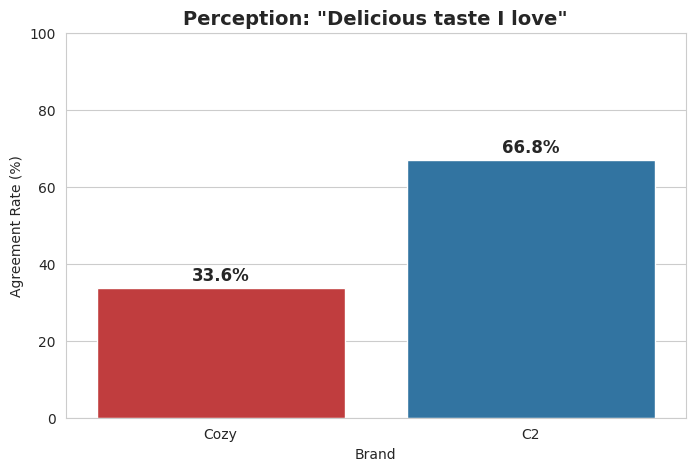

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select Columns for the 'Taste I love' attribute
cozy_taste_col = 'QI - Trà Cozy đóng chai_Vị ngon mà tôi yêu thích'
c2_taste_col = 'QI - C2_Vị ngon mà tôi yêu thích'

def calculate_agreement_rate(df, col_name):
    # 2. Data Cleaning: remove nulls/NaNs
    clean_data = df[col_name].astype(str).str.strip().str.lower()
    clean_data = clean_data[~clean_data.isin(['nan', '#null!', '', 'none'])]

    # 3. Calculate %
    total = len(clean_data)
    if total == 0: return 0.0, 0

    # Count 'Yes' (1, yes, selected)
    yes_count = clean_data[clean_data.isin(['1', 'yes', 'selected', 'checked'])].count()
    percentage = (yes_count / total) * 100
    return percentage, total

# Calculate for both brands
cozy_rate, cozy_sample = calculate_agreement_rate(df, cozy_taste_col)
c2_rate, c2_sample = calculate_agreement_rate(df, c2_taste_col)

# 4. Results Presentation
results_df = pd.DataFrame({
    'Brand': ['Cozy', 'C2'],
    'Taste_Score_%': [cozy_rate, c2_rate],
    'Sample_Size': [cozy_sample, c2_sample]
})

print("--- Brand Image Verification Result ---")
display(results_df)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='Brand', y='Taste_Score_%', data=results_df, palette=['#d62728', '#1f77b4'])
plt.title('Perception: "Delicious taste I love"', fontsize=14, fontweight='bold')
plt.ylabel('Agreement Rate (%)')
plt.ylim(0, 100)

for i, v in enumerate(results_df['Taste_Score_%']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.show()

### So sánh Hình ảnh Thương hiệu diện rộng: "Vị ngon mà tôi yêu thích" (QI - R7)
Phân tích tỷ lệ đồng ý về hương vị của Cozy so với tất cả các đối thủ cạnh tranh chính trong danh mục trà đóng chai.

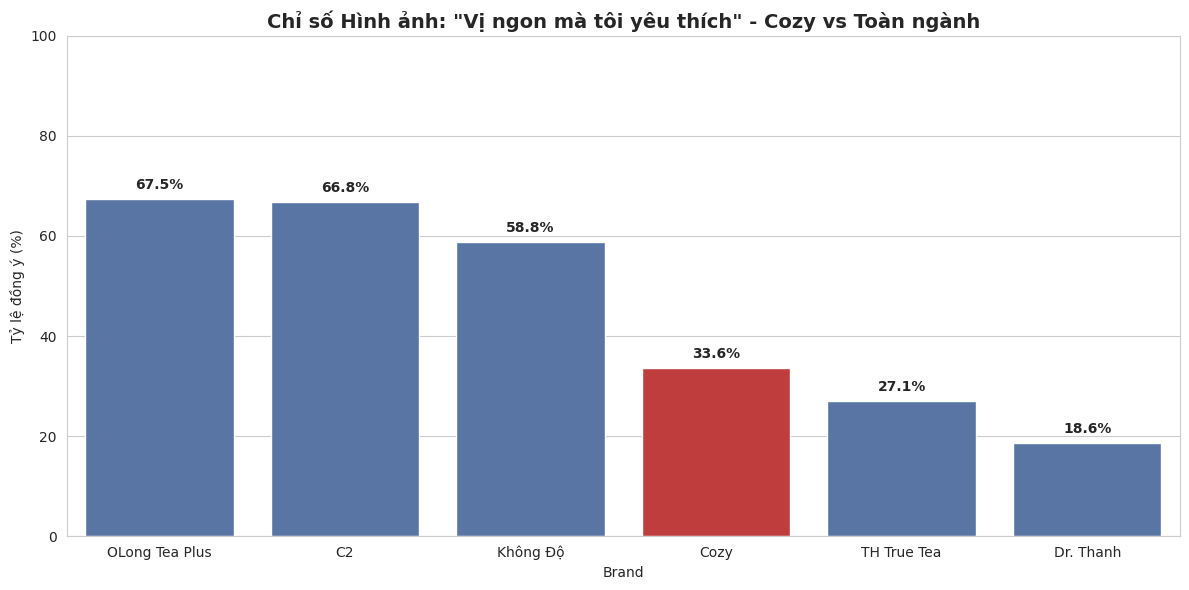

,Brand,Taste_Score_%,Sample
2,OLong Tea Plus,67.470817,2570
1,C2,66.825020,2526
3,Không Độ,58.818636,2404
0,Cozy,33.640553,2387
5,TH True Tea,27.104247,1295
4,Dr. Thanh,18.578947,1900


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Danh sách các thương hiệu cần so sánh và từ khóa tương ứng trong cột QI
brands_to_compare = {
    'Cozy': 'Trà Cozy',
    'C2': 'C2',
    'OLong Tea Plus': 'OLong Tea Plus',
    'Không Độ': 'Không Độ',
    'Dr. Thanh': 'Dr. Thanh',
    'TH True Tea': 'TH True Tea'
}

attribute_keyword = 'Vị ngon mà tôi yêu thích'
comparison_results = []

def get_rate(brand_keyword):
    # Tìm cột QI cho thương hiệu này với thuộc tính vị ngon
    target_cols = [col for col in df.columns if 'QI' in col and brand_keyword in col and attribute_keyword in col]
    if not target_cols:
        return None, 0

    col = target_cols[0]
    # Làm sạch dữ liệu
    clean_data = df[col].astype(str).str.strip().str.lower()
    clean_data = clean_data[~clean_data.isin(['nan', '#null!', '', 'none'])]

    total = len(clean_data)
    if total == 0: return 0.0, 0

    # Tính % đồng ý (Yes)
    yes_count = clean_data[clean_data.isin(['1', 'yes', 'selected', 'checked'])].count()
    return (yes_count / total) * 100, total

# 2. Thu thập dữ liệu cho tất cả các brands
for display_name, keyword in brands_to_compare.items():
    rate, sample = get_rate(keyword)
    if rate is not None:
        comparison_results.append({
            'Brand': display_name,
            'Taste_Score_%': rate,
            'Sample': sample
        })

# 3. Tạo DataFrame và vẽ biểu đồ
full_comp_df = pd.DataFrame(comparison_results).sort_values('Taste_Score_%', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Sử dụng màu đỏ nổi bật cho Cozy, các brand khác màu xám xanh
colors = ['#d62728' if x == 'Cozy' else '#4c72b0' for x in full_comp_df['Brand']]

ax = sns.barplot(x='Brand', y='Taste_Score_%', data=full_comp_df, palette=colors, hue='Brand', legend=False)

plt.title('Chỉ số Hình ảnh: "Vị ngon mà tôi yêu thích" - Cozy vs Toàn ngành', fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ đồng ý (%)')
plt.ylim(0, 100)

for i, v in enumerate(full_comp_df['Taste_Score_%']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

display(full_comp_df)

### So sánh diện rộng: Chỉ số "Vị ngon mà tôi yêu thích" cho tất cả 13 thương hiệu
Phân tích đầy đủ vị thế của Cozy so với mọi đối thủ trong danh sách khảo sát.

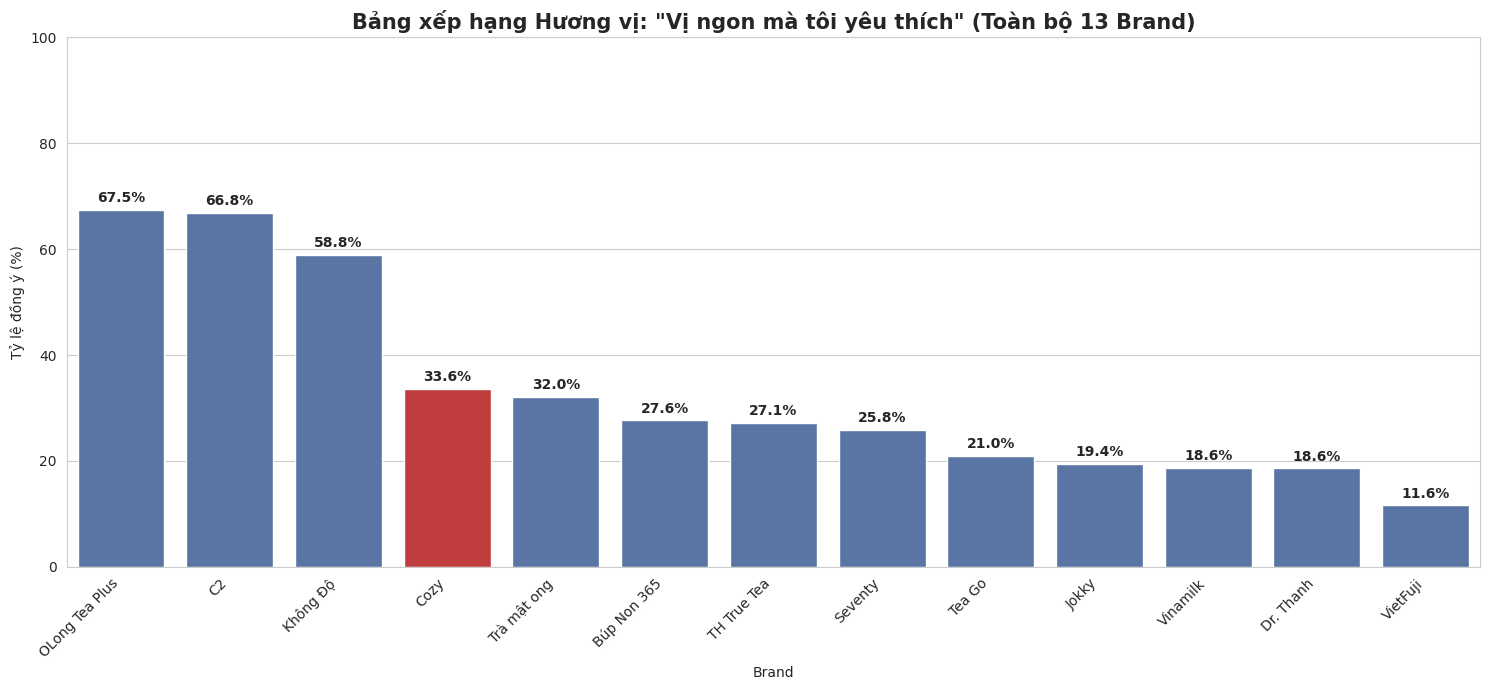

,Brand,Taste_Score_%,Sample
2,OLong Tea Plus,67.470817,2570
1,C2,66.825020,2526
3,Không Độ,58.818636,2404
0,Cozy,33.640553,2387
6,Trà mật ong,31.996792,1247
9,Búp Non 365,27.643065,1031
5,TH True Tea,27.104247,1295
8,Seventy,25.773196,679
7,Tea Go,20.953327,1007
12,Jokky,19.402985,67


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Danh sách đầy đủ 13 thương hiệu dựa trên dữ liệu kernel
full_brand_list = {
    'Cozy': 'Trà Cozy',
    'C2': 'C2',
    'OLong Tea Plus': 'OLong Tea Plus',
    'Không Độ': 'Không Độ',
    'Dr. Thanh': 'Dr. Thanh',
    'TH True Tea': 'TH True Tea',
    'Trà mật ong': 'mật ong',
    'Tea Go': 'Tea Go',
    'Seventy': 'Seventy',
    'Búp Non 365': '365',
    'Vinamilk': 'Vinamilk',
    'VietFuji': 'VietFuji',
    'Jokky': 'Jokky'
}

attribute_keyword = 'Vị ngon mà tôi yêu thích'
all_results = []

def get_agreement_rate(brand_kw):
    # Tìm cột QI tương ứng
    target_cols = [col for col in df.columns if 'QI' in col and brand_kw.lower() in col.lower() and attribute_keyword in col]
    if not target_cols:
        return None, 0

    col = target_cols[0]
    # Làm sạch dữ liệu: loại bỏ null và lấy các giá trị đồng ý
    valid_series = df[col].astype(str).str.strip().str.lower()
    valid_series = valid_series[~valid_series.isin(['nan', '#null!', '', 'none'])]

    total = len(valid_series)
    if total == 0: return 0.0, 0

    yes_count = valid_series[valid_series.isin(['1', 'yes', 'selected', 'checked'])].count()
    return (yes_count / total) * 100, total

# 2. Thu thập dữ liệu
for display_name, kw in full_brand_list.items():
    rate, sample = get_agreement_rate(kw)
    if rate is not None:
        all_results.append({'Brand': display_name, 'Taste_Score_%': rate, 'Sample': sample})

# 3. Trực quan hóa
final_comp_df = pd.DataFrame(all_results).sort_values('Taste_Score_%', ascending=False)

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")
colors = ['#d62728' if x == 'Cozy' else '#4c72b0' for x in final_comp_df['Brand']]

ax = sns.barplot(x='Brand', y='Taste_Score_%', data=final_comp_df, palette=colors, hue='Brand', legend=False)

plt.title('Bảng xếp hạng Hương vị: "Vị ngon mà tôi yêu thích" (Toàn bộ 13 Brand)', fontsize=15, fontweight='bold')
plt.ylabel('Tỷ lệ đồng ý (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

for i, v in enumerate(final_comp_df['Taste_Score_%']):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

display(final_comp_df)

### Kiểm định Ý tưởng 2: So sánh Hình ảnh Thương hiệu (QI - R7) - Cozy vs C2
**Mục tiêu:** Xác minh tỷ lệ % khách hàng đồng ý với thuộc tính "Vị ngon mà tôi yêu thích" để kiểm chứng khoảng cách về cảm nhận hương vị.

In [51]:
# Bước 1: Chọn cột
cozy_qi_col = 'QI - Trà Cozy đóng chai_Vị ngon mà tôi yêu thích'
c2_qi_col = 'QI - C2_Vị ngon mà tôi yêu thích'

def calculate_qi_rate(column_name):
    # Bước 2: Làm sạch dữ liệu (loại bỏ null)
    series = df[column_name].astype(str).str.strip().str.lower()
    valid_series = series[~series.isin(['nan', '#null!', '', 'none'])]

    # Bước 3 & 4: Tính toán
    total_responses = len(valid_series)
    if total_responses == 0: return 0, 0

    num_yes = valid_series[valid_series.isin(['1', 'yes', 'selected', 'checked'])].count()
    percentage = (num_yes / total_responses) * 100
    return percentage, total_responses

cozy_perc, cozy_total = calculate_qi_rate(cozy_qi_col)
c2_perc, c2_total = calculate_qi_rate(c2_qi_col)

# Bước 5: Hiển thị kết quả đối chiếu
print(f"--- Kết quả Kiểm định QI (Vị ngon mà tôi yêu thích) ---")
print(f"Cozy: {cozy_perc:.1f}% (Dựa trên n={cozy_total} câu trả lời)")
print(f"C2:   {c2_perc:.1f}% (Dựa trên n={c2_total} câu trả lời)")
print(f"Khoảng cách: {c2_perc/cozy_perc:.2f} lần")

--- Kết quả Kiểm định QI (Vị ngon mà tôi yêu thích) ---
Cozy: 33.6% (Dựa trên n=2387 câu trả lời)
C2:   66.8% (Dựa trên n=2526 câu trả lời)
Khoảng cách: 1.99 lần


### Tổng quan Mẫu khảo sát (Sample Profile)
Thống kê cơ cấu mẫu theo các biến nhân khẩu học chính: Khu vực, Giới tính, Độ tuổi và Thu nhập (N=2600).

Tổng mẫu: 2600 người


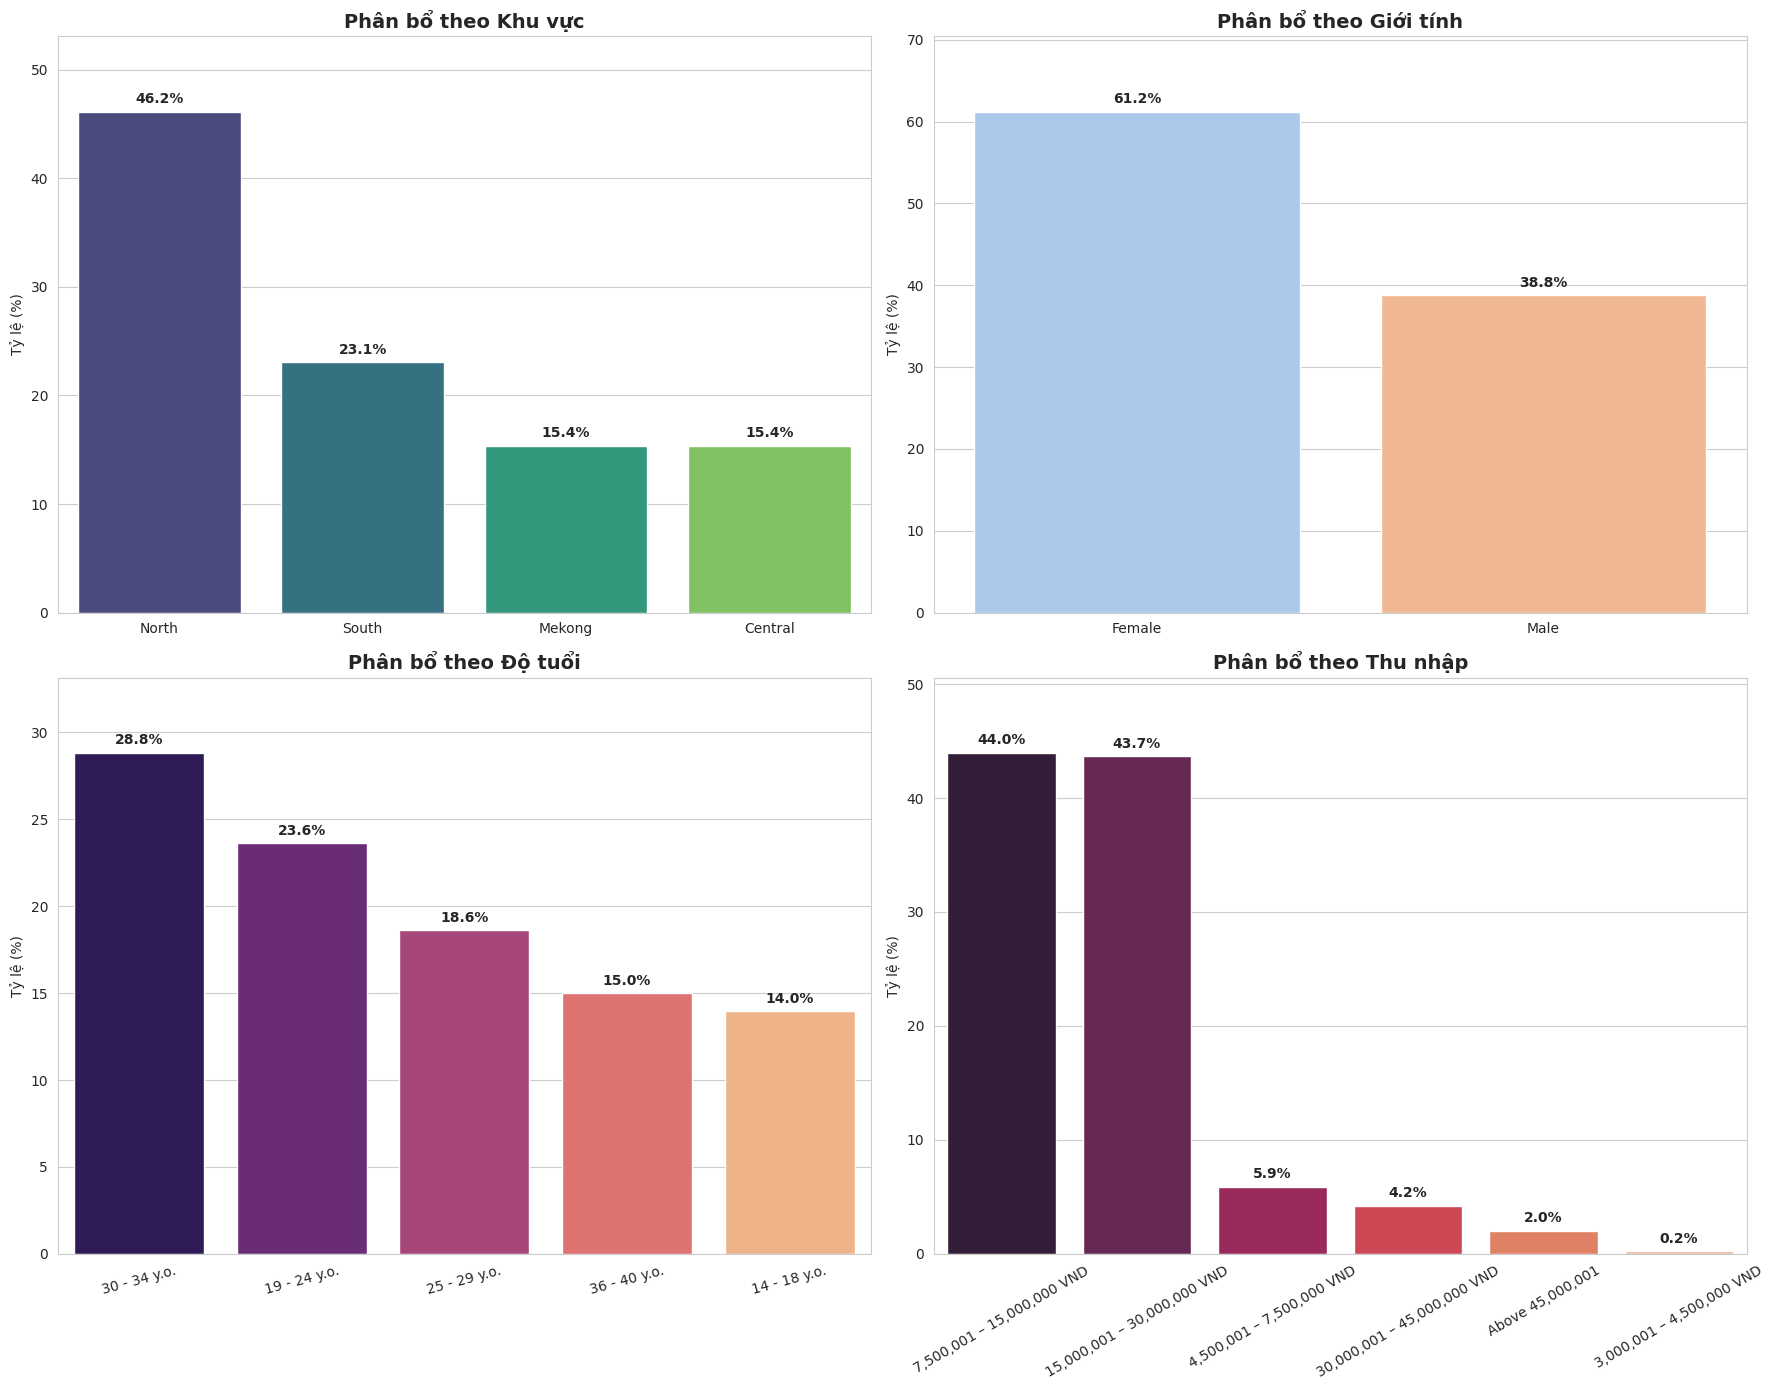

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_summary_table(df, column_name, label):
    summary = df[column_name].value_counts().reset_index()
    summary.columns = [label, 'Số lượng']
    summary['Tỷ lệ (%)'] = (summary['Số lượng'] / len(df)) * 100
    return summary

# 1. Thống kê theo các chiều
region_sum = get_summary_table(df, 'Region', 'Khu vực')
gender_sum = get_summary_table(df, 'D2.Gender', 'Giới tính')
age_sum = get_summary_table(df, 'D3.Age', 'Độ tuổi')
income_sum = get_summary_table(df, 'D4.Income', 'Thu nhập')

# 2. Hiển thị các bảng
print(f"Tổng mẫu: {len(df)} người")

# 3. Trực quan hóa dạng cột đứng với nhãn %
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sns.set_style("whitegrid")

def plot_vertical_bar(data, x_col, y_col, ax, title, palette):
    bar = sns.barplot(data=data, x=x_col, y=y_col, ax=ax, palette=palette, hue=x_col, legend=False)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.set_xlabel('')
    ax.set_ylim(0, data[y_col].max() * 1.15)
    # Thêm nhãn %
    for p in bar.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontweight='bold')

plot_vertical_bar(region_sum, 'Khu vực', 'Tỷ lệ (%)', axes[0, 0], 'Phân bổ theo Khu vực', 'viridis')
plot_vertical_bar(gender_sum, 'Giới tính', 'Tỷ lệ (%)', axes[0, 1], 'Phân bổ theo Giới tính', 'pastel')
plot_vertical_bar(age_sum, 'Độ tuổi', 'Tỷ lệ (%)', axes[1, 0], 'Phân bổ theo Độ tuổi', 'magma')
plot_vertical_bar(income_sum, 'Thu nhập', 'Tỷ lệ (%)', axes[1, 1], 'Phân bổ theo Thu nhập', 'rocket')

# Xoay nhãn trục x cho cột thu nhập và tuổi để tránh chồng lấn
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Phân tích Phễu thương hiệu Toàn cảnh (Full Brand Funnel Analysis)
Bao gồm các chỉ số:
- **TOM (Top of Mind):** Nhận diện đầu tiên.
- **Spontaneous:** Nhận diện tự hồi tưởng.
- **Aided:** Nhận diện có trợ giúp.
- **Consideration:** Cân nhắc mua.
- **P3M/P4W:** Sử dụng trong 3 tháng/4 tuần qua.
- **BUMO:** Thương hiệu sử dụng thường xuyên nhất.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def check_selected(val):
    s = str(val).strip().lower()
    return s in ['1', 'yes', 'selected', 'checked']

# Cấu hình đầy đủ 13 brands với keyword tìm kiếm và nhãn chuẩn hóa
full_brands_config = {
    'Cozy': {'kw': 'cozy', 'lbl': 'Cozy'},
    'C2': {'kw': 'c2', 'lbl': 'C2'},
    'OLong Tea Plus': {'kw': 'olong tea plus', 'lbl': 'OLong Tea Plus'},
    'Không Độ': {'kw': 'không độ', 'lbl': 'Không Độ'},
    'Dr. Thanh': {'kw': 'dr. thanh', 'lbl': 'Dr. Thanh'},
    'TH True Tea': {'kw': 'th true tea', 'lbl': 'TH True Tea'},
    'Trà mật ong': {'kw': 'mật ong', 'lbl': 'Trà mật ong'},
    'Tea Go': {'kw': 'tea go', 'lbl': 'Tea Go'},
    'Seventy': {'kw': 'seventy', 'lbl': 'Seventy'},
    'Búp Non 365': {'kw': '365', 'lbl': 'Búp Non 365'},
    'Vinamilk': {'kw': 'vinamilk', 'lbl': 'Vinamilk'},
    'VietFuji': {'kw': 'vietfuji', 'lbl': 'VietFuji'},
    'Jokky': {'kw': 'jokky', 'lbl': 'Jokky'}
}

funnel_13_results = []
TOTAL_N = 2600

for display_name, cfg in full_brands_config.items():
    kw = cfg['kw'].lower()
    lbl = cfg['lbl']

    # 1. TOM (Q1.TOM)
    tom_count = df['Q1.TOM'].str.contains(lbl, case=False, na=False).sum()

    # 2. BUMO (Q5.Bumo)
    bumo_count = df['Q5.Bumo'].str.contains(lbl, case=False, na=False).sum()

    # 3. Các chỉ số khác từ cột đa lựa chọn
    spon_cols = [c for c in df.columns if 'Q1.Total Spontaneous' in c and kw in c.lower()]
    aided_cols = [c for c in df.columns if 'Q1Q2. Total aided awareness' in c and kw in c.lower()]
    cons_cols = [c for c in df.columns if 'Q4Q8.BRAND CONSIDERATION SET' in c and kw in c.lower()]
    p3m_cols = [c for c in df.columns if 'Q3. P3M' in c and kw in c.lower()]
    p4w_cols = [c for c in df.columns if 'Q4. P4W' in c and kw in c.lower()]

    def get_count(cols):
        if not cols: return 0
        return df[cols].apply(lambda row: row.apply(check_selected).any(), axis=1).sum()

    funnel_13_results.append({
        'Brand': display_name,
        'TOM': (tom_count/TOTAL_N)*100,
        'Spontaneous': (get_count(spon_cols)/TOTAL_N)*100,
        'Total Awareness': (get_count(aided_cols)/TOTAL_N)*100,
        'Consideration': (get_count(cons_cols)/TOTAL_N)*100,
        'P3M': (get_count(p3m_cols)/TOTAL_N)*100,
        'P4W': (get_count(p4w_cols)/TOTAL_N)*100,
        'BUMO': (bumo_count/TOTAL_N)*100
    })

final_funnel_13_df = pd.DataFrame(funnel_13_results).sort_values('P4W', ascending=False)

print("--- Bảng Phễu Thương hiệu đầy đủ 13 Brand (%) ---")
display(final_funnel_13_df.style.format(precision=1).background_gradient(cmap='YlOrRd', subset=['P4W', 'BUMO']))

--- Bảng Phễu Thương hiệu đầy đủ 13 Brand (%) ---


,Brand,TOM,Spontaneous,Total Awareness,Consideration,P3M,P4W,BUMO
1,C2,35.8,78.9,97.3,76.0,66.3,57.7,32.2
2,OLong Tea Plus,27.9,75.7,98.8,74.8,66.8,54.0,29.4
3,Không Độ,22.4,54.2,92.5,61.3,47.6,37.3,20.8
0,Cozy,8.7,39.6,91.8,34.7,33.2,25.8,8.8
6,Trà mật ong,0.7,3.5,48.0,20.1,9.2,7.9,2.3
5,TH True Tea,1.2,5.4,49.8,17.8,8.8,5.8,1.7
4,Dr. Thanh,0.7,4.9,73.1,16.3,9.9,5.4,1.3
9,Búp Non 365,1.1,3.9,39.7,14.3,5.3,3.7,1.4
8,Seventy,0.0,0.2,26.1,6.3,5.4,3.0,1.1
7,Tea Go,0.1,1.0,38.7,9.2,4.7,2.3,0.3


### Biểu đồ So sánh Phễu Thương hiệu (13 Brands)
Biểu đồ này hiển thị hành trình từ Nhận diện (TOM) đến Trung thành (BUMO) của khách hàng đối với tất cả 13 thương hiệu trà đóng chai.

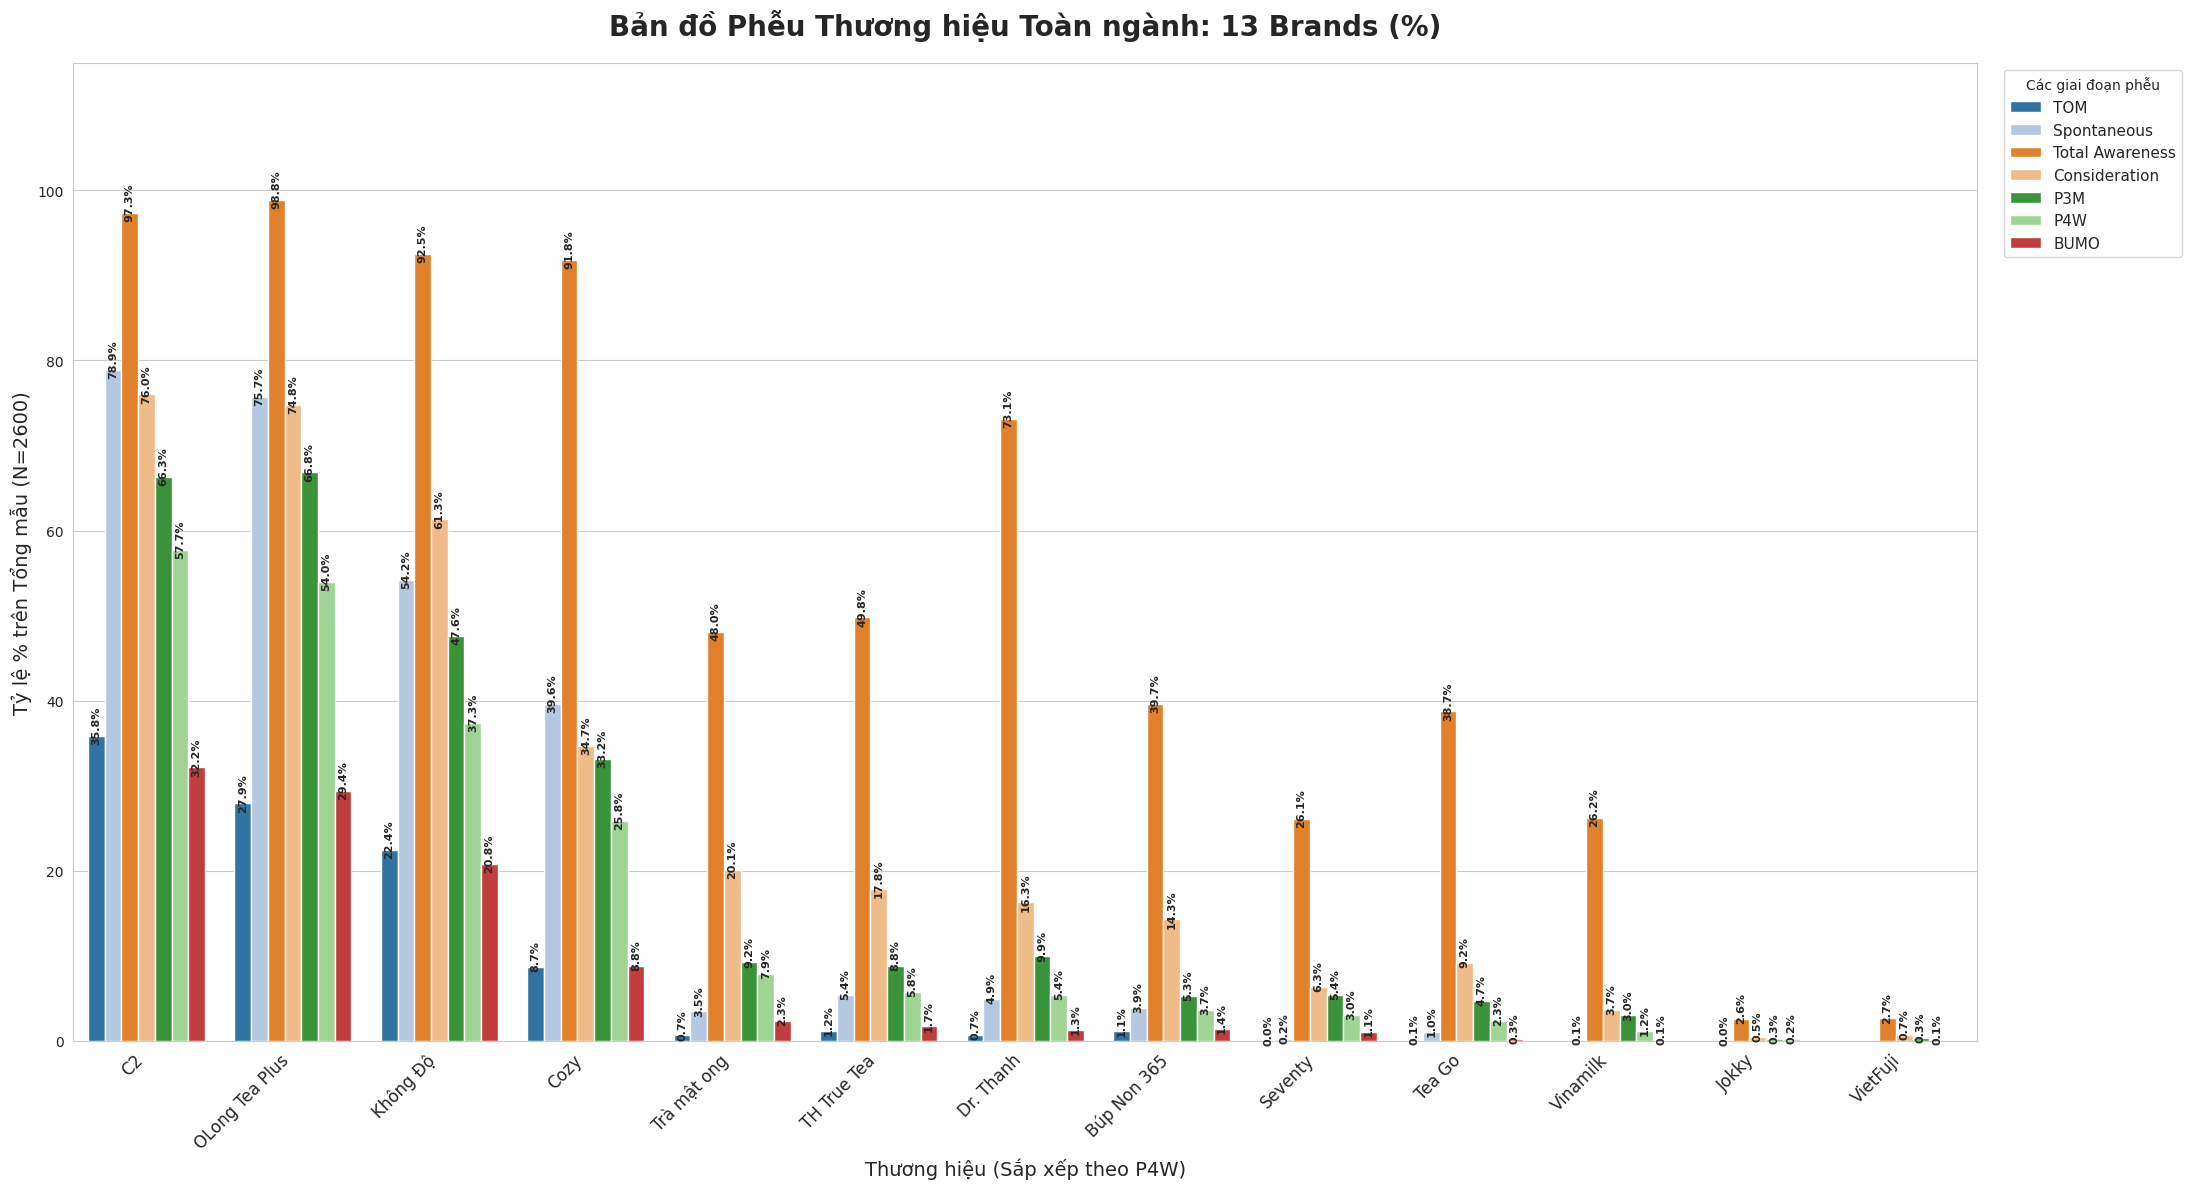

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sử dụng dữ liệu đã có từ cell trước: final_funnel_13_df
# Chúng ta sẽ lọc bỏ các giai đoạn trung gian nếu cần để biểu đồ bớt rối,
# nhưng ở đây sẽ vẽ đầy đủ theo yêu cầu.

plt.figure(figsize=(22, 12))
sns.set_style("whitegrid")

# Melt dữ liệu để dùng cho seaborn barplot
plot_full_df = final_funnel_13_df.melt(id_vars='Brand', var_name='Giai đoạn', value_name='Tỷ lệ (%)')

# Vẽ biểu đồ
ax = sns.barplot(data=plot_full_df, x='Brand', y='Tỷ lệ (%)', hue='Giai đoạn', palette='tab20')

plt.title('Bản đồ Phễu Thương hiệu Toàn ngành: 13 Brands (%)', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ % trên Tổng mẫu (N=2600)', fontsize=14)
plt.xlabel('Thương hiệu (Sắp xếp theo P4W)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(0, 115)
plt.legend(title='Các giai đoạn phễu', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)

# Thêm nhãn số liệu cho 2 chỉ số quan trọng nhất: TOM và BUMO
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Chỉ hiển thị nhãn nếu là cột TOM hoặc BUMO để tránh bị đè chữ quá nhiều
        # Hoặc hiển thị tất cả nhưng với font nhỏ
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=8, fontweight='bold', rotation=90)

plt.tight_layout()
plt.show()

### Phân tích Thay đổi Usage P4W (Wave 2024 vs 2025) - Toàn bộ 13 Brands
So sánh chi tiết mức độ tăng trưởng hoặc sụt giảm thị phần sử dụng thực tế của tất cả các thương hiệu qua hai năm khảo sát.

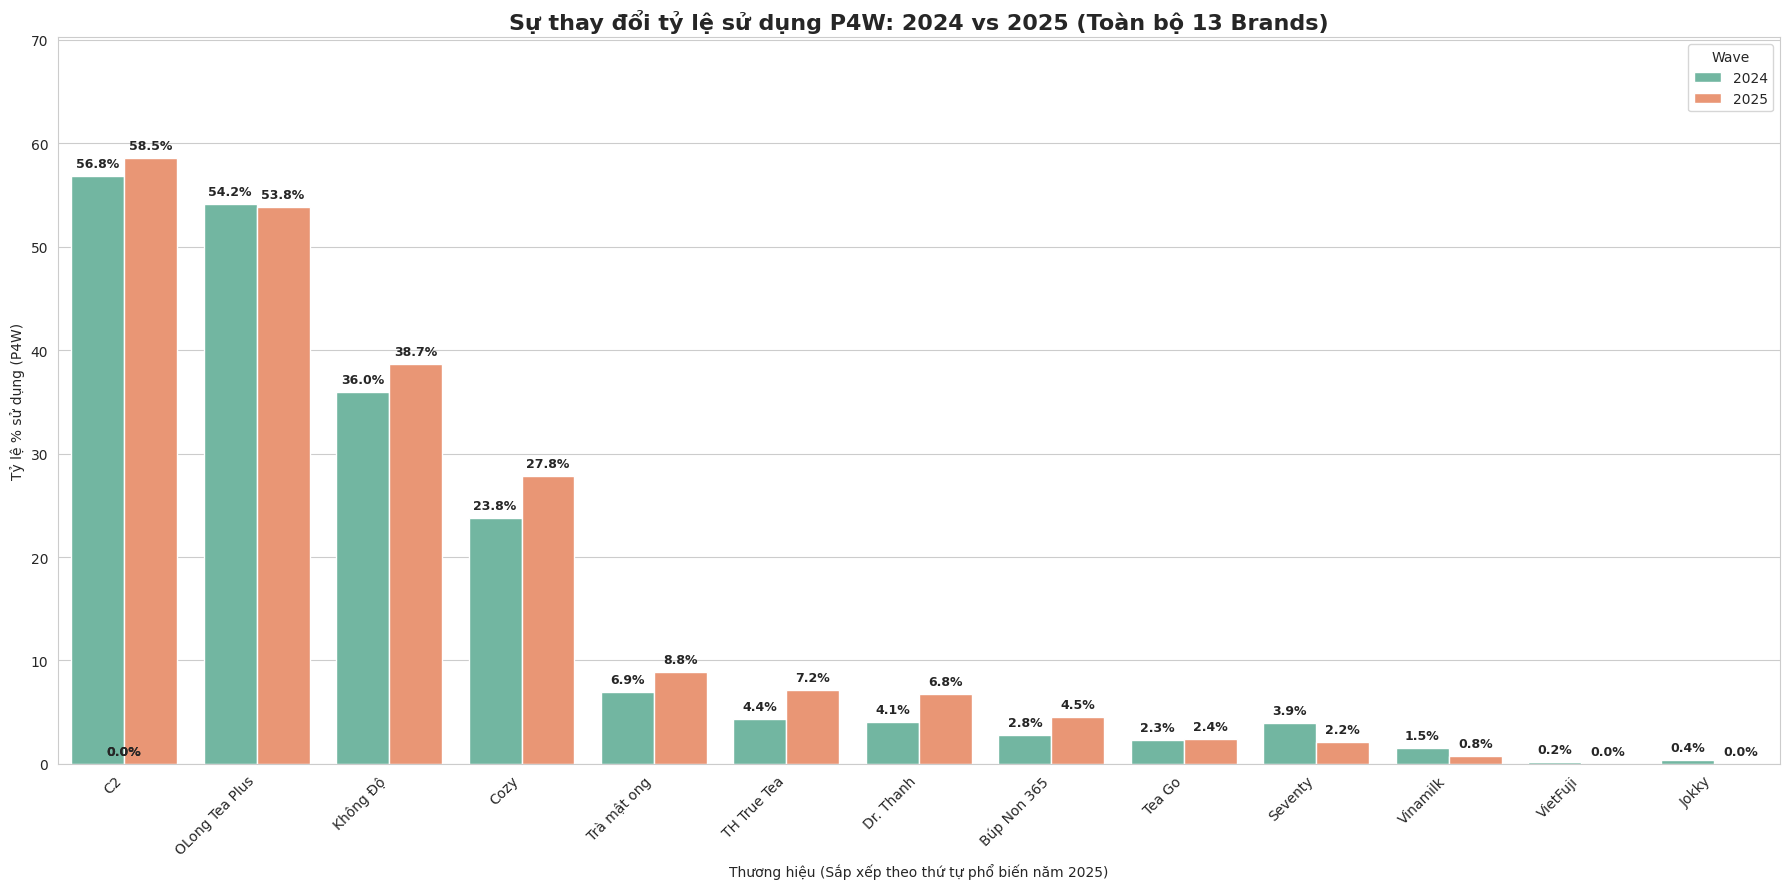

Wave,2024,2025,Delta
Brand,,,
C2,56.8,58.5,1.7
OLong Tea Plus,54.2,53.8,-0.3
Không Độ,36.0,38.7,2.7
Cozy,23.8,27.8,4.1
Trà mật ong,6.9,8.8,1.9
TH True Tea,4.4,7.2,2.8
Dr. Thanh,4.1,6.8,2.7
Búp Non 365,2.8,4.5,1.8
Tea Go,2.3,2.4,0.1


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def check_selected(val):
    s = str(val).strip().lower()
    return s in ['1', 'yes', 'selected', 'checked']

# Sử dụng cấu hình 13 brands đã định nghĩa ở các cell trước
full_brands_list = {
    'Cozy': 'cozy',
    'C2': 'c2',
    'OLong Tea Plus': 'olong tea plus',
    'Không Độ': 'không độ',
    'Dr. Thanh': 'dr. thanh',
    'TH True Tea': 'th true tea',
    'Trà mật ong': 'mật ong',
    'Tea Go': 'tea go',
    'Seventy': 'seventy',
    'Búp Non 365': '365',
    'Vinamilk': 'vinamilk',
    'VietFuji': 'vietfuji',
    'Jokky': 'jokky'
}

waves = [2024, 2025]
usage_13_comparison = []

for year in waves:
    wave_df = df[df['Wave'].astype(str).str.contains(str(year))]
    n_size = len(wave_df)

    if n_size == 0: continue

    for display_name, kw in full_brands_list.items():
        p4w_cols = [c for c in df.columns if 'Q4. P4W' in c and kw in c.lower()]

        if p4w_cols:
            p4w_count = wave_df[p4w_cols].apply(lambda row: row.apply(check_selected).any(), axis=1).sum()
            rate = (p4w_count / n_size) * 100
        else:
            rate = 0.0

        usage_13_comparison.append({
            'Wave': str(year),
            'Brand': display_name,
            'P4W Rate': rate
        })

usage_13_compare_df = pd.DataFrame(usage_13_comparison)

# Sắp xếp theo P4W của Wave 2025 để biểu đồ dễ nhìn
sort_order_2025 = usage_13_compare_df[usage_13_compare_df['Wave'] == '2025'].sort_values('P4W Rate', ascending=False)['Brand']

plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")
ax = sns.barplot(data=usage_13_compare_df, x='Brand', y='P4W Rate', hue='Wave', order=sort_order_2025, palette='Set2')

plt.title('Sự thay đổi tỷ lệ sử dụng P4W: 2024 vs 2025 (Toàn bộ 13 Brands)', fontsize=16, fontweight='bold')
plt.ylabel('Tỷ lệ % sử dụng (P4W)')
plt.xlabel('Thương hiệu (Sắp xếp theo thứ tự phổ biến năm 2025)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, usage_13_compare_df['P4W Rate'].max() * 1.2)

# Thêm nhãn số liệu
for p in ax.patches:
    h = p.get_height()
    if h >= 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center', xytext=(0, 9),
                    textcoords='offset points', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Hiển thị bảng pivot để xem mức tăng trưởng (Delta)
pivot_table = usage_13_compare_df.pivot(index='Brand', columns='Wave', values='P4W Rate')
pivot_table['Delta'] = pivot_table['2025'] - pivot_table['2024']
display(pivot_table.sort_values('2025', ascending=False).style.format(precision=1))

### Phân tích Thay đổi Usage P3M (Wave 2024 vs 2025) - Toàn bộ 13 Brands
So sánh tỷ lệ người dùng sử dụng sản phẩm trong 3 tháng qua để đánh giá sự thay đổi về độ phủ thương hiệu tổng thể.

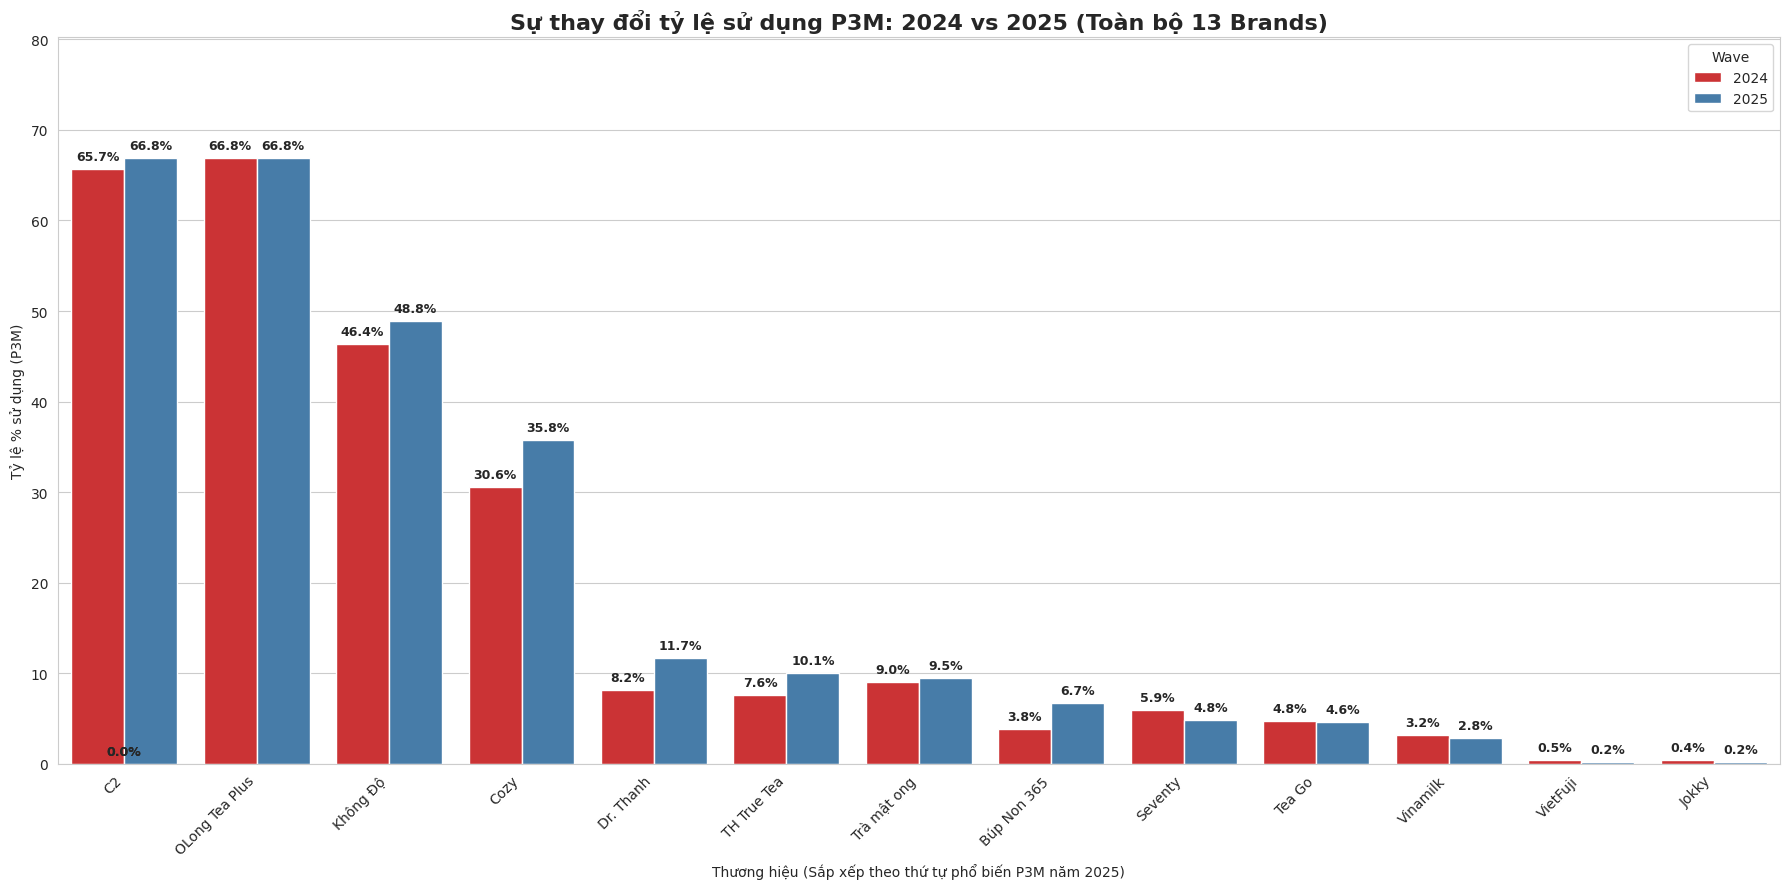

Wave,2024,2025,Delta
Brand,,,
C2,65.7,66.8,1.2
OLong Tea Plus,66.8,66.8,0.0
Không Độ,46.4,48.8,2.5
Cozy,30.6,35.8,5.2
Dr. Thanh,8.2,11.7,3.5
TH True Tea,7.6,10.1,2.5
Trà mật ong,9.0,9.5,0.5
Búp Non 365,3.8,6.7,2.8
Seventy,5.9,4.8,-1.1


In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def check_selected(val):
    s = str(val).strip().lower()
    return s in ['1', 'yes', 'selected', 'checked']

full_brands_list = {
    'Cozy': 'cozy',
    'C2': 'c2',
    'OLong Tea Plus': 'olong tea plus',
    'Không Độ': 'không độ',
    'Dr. Thanh': 'dr. thanh',
    'TH True Tea': 'th true tea',
    'Trà mật ong': 'mật ong',
    'Tea Go': 'tea go',
    'Seventy': 'seventy',
    'Búp Non 365': '365',
    'Vinamilk': 'vinamilk',
    'VietFuji': 'vietfuji',
    'Jokky': 'jokky'
}

waves = [2024, 2025]
usage_p3m_comparison = []

for year in waves:
    wave_df = df[df['Wave'].astype(str).str.contains(str(year))]
    n_size = len(wave_df)

    if n_size == 0: continue

    for display_name, kw in full_brands_list.items():
        p3m_cols = [c for c in df.columns if 'Q3. P3M' in c and kw in c.lower()]

        if p3m_cols:
            p3m_count = wave_df[p3m_cols].apply(lambda row: row.apply(check_selected).any(), axis=1).sum()
            rate = (p3m_count / n_size) * 100
        else:
            rate = 0.0

        usage_p3m_comparison.append({
            'Wave': str(year),
            'Brand': display_name,
            'P3M Rate': rate
        })

usage_p3m_compare_df = pd.DataFrame(usage_p3m_comparison)

# Sắp xếp theo P3M của Wave 2025
sort_order_p3m = usage_p3m_compare_df[usage_p3m_compare_df['Wave'] == '2025'].sort_values('P3M Rate', ascending=False)['Brand']

plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")
ax = sns.barplot(data=usage_p3m_compare_df, x='Brand', y='P3M Rate', hue='Wave', order=sort_order_p3m, palette='Set1')

plt.title('Sự thay đổi tỷ lệ sử dụng P3M: 2024 vs 2025 (Toàn bộ 13 Brands)', fontsize=16, fontweight='bold')
plt.ylabel('Tỷ lệ % sử dụng (P3M)')
plt.xlabel('Thương hiệu (Sắp xếp theo thứ tự phổ biến P3M năm 2025)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, usage_p3m_compare_df['P3M Rate'].max() * 1.2)

for p in ax.patches:
    h = p.get_height()
    if h >= 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center', xytext=(0, 9),
                    textcoords='offset points', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Bảng so sánh Delta P3M
pivot_p3m = usage_p3m_compare_df.pivot(index='Brand', columns='Wave', values='P3M Rate')
pivot_p3m['Delta'] = pivot_p3m['2025'] - pivot_p3m['2024']
display(pivot_p3m.sort_values('2025', ascending=False).style.format(precision=1))

In [91]:
import pandas as pd
import numpy as np
df = pd.read_excel("/content/myInsight 2026_V2_Dataset.xlsx", sheet_name='Dataset')
brands = ['C2', 'Không Độ', 'Trà Cozy đóng chai', 'Dr. Thanh', 'OLong Tea Plus', 'Búp non 365', 'Trà TH True Tea']

imagery_attrs = [
    'Những thương hiệu được ưa chuộng và phổ biến',
    'Bao bì có thiết kế thu hút',
    'Nhãn hiệu đáng tin cậy',
    'Giá cả hợp lý với chất lượng mang lại',
    'Phù hợp để thưởng thức hàng ngày',
    'Làm dịu cơn khát',
    'Vị ngon mà tôi yêu thích',
    'Thương hiệu mang tính hiện đại, trẻ trung',
    'Sản xuất từ nguyên liệu tự nhiên',
    'Có lợi cho sức khỏe',
    'Giúp giảm căng thẳng và mệt mỏi',
    'Mang lại cảm giác thư giãn',
    'Tạo cảm giác sảng khoái',
    'Tái tạo năng lượng',
    'Có nhiều vị để lựa chọn',
    'Mang đến cảm giác tươi mát',
]

print("=== BRAND IMAGERY (% who associate attribute with brand) ===")
print(f"{'Attribute':<45}", end='')
for b in brands:
    short = b.replace('Trà Cozy đóng chai','Cozy').replace('OLong Tea Plus','OTP').replace('Trà TH True Tea','TH Tea').replace('Búp non 365','Búp 365')
    print(f"{short:>10}", end='')
print()
print("-"*115)

for attr in imagery_attrs:
    row = f"{attr:<45}"
    for b in brands:
        col = f'QI - {b}_{attr}'
        if col in df.columns:
            pct = df[col].eq('Yes').mean()*100
            row += f"{pct:>9.1f}%"
        else:
            row += f"{'N/A':>10}"
    print(row)

# === BARRIER ANALYSIS ===
print("\n\n=== BARRIER TO CONSIDER (% among non-users) ===")
barrier_attrs = [
    'Do not like the flavor/The flavor do not taste good',
    'Unhealthy',
    'Do not trust in product quality',
    'Expensive than I expected',
    'Does not have enough flavour that I want to choose',
    'Has higher sugar than I needed',
    'Unpopular brands',
    'Do not like recent packaging designs',
    'Asked but the store does not sell it',
    'Not preserved in cool place',
]

print(f"{'Barrier':<45}", end='')
for b in ['C2','Không Độ','Trà Cozy đóng chai','Dr. Thanh','OLong Tea Plus']:
    short = b.replace('Trà Cozy đóng chai','Cozy').replace('OLong Tea Plus','OTP')
    print(f"{short:>12}", end='')
print()
print("-"*105)

for attr in barrier_attrs:
    row = f"{attr:<45}"
    for b in ['C2','Không Độ','Trà Cozy đóng chai','Dr. Thanh','OLong Tea Plus']:
        col = f'QME2 - {b}_{attr}'
        if col in df.columns:
            pct = df[col].eq('Yes').mean()*100
            row += f"{pct:>11.1f}%"
        else:
            row += f"{'N/A':>12}"
    print(row)


=== BRAND IMAGERY (% who associate attribute with brand) ===
Attribute                                            C2  Không Độ      Cozy Dr. Thanh       OTP   Búp 365    TH Tea
-------------------------------------------------------------------------------------------------------------------
Những thương hiệu được ưa chuộng và phổ biến      82.4%     67.0%     49.8%     27.1%     87.5%     12.1%     14.7%
Bao bì có thiết kế thu hút                        71.0%     62.7%     44.1%     20.3%     67.0%     22.4%     26.4%
Nhãn hiệu đáng tin cậy                            75.2%     67.9%     51.0%     29.8%     80.2%     18.3%     19.7%
Giá cả hợp lý với chất lượng mang lại             68.6%     61.0%     39.3%     20.8%     71.5%     14.6%     15.9%
Phù hợp để thưởng thức hàng ngày                  61.6%     53.6%     31.6%     15.7%     65.5%     11.7%     13.2%
Làm dịu cơn khát                                  75.4%     65.5%     44.0%     26.9%     79.2%     17.5%     21.2%
Vị ngon mà 

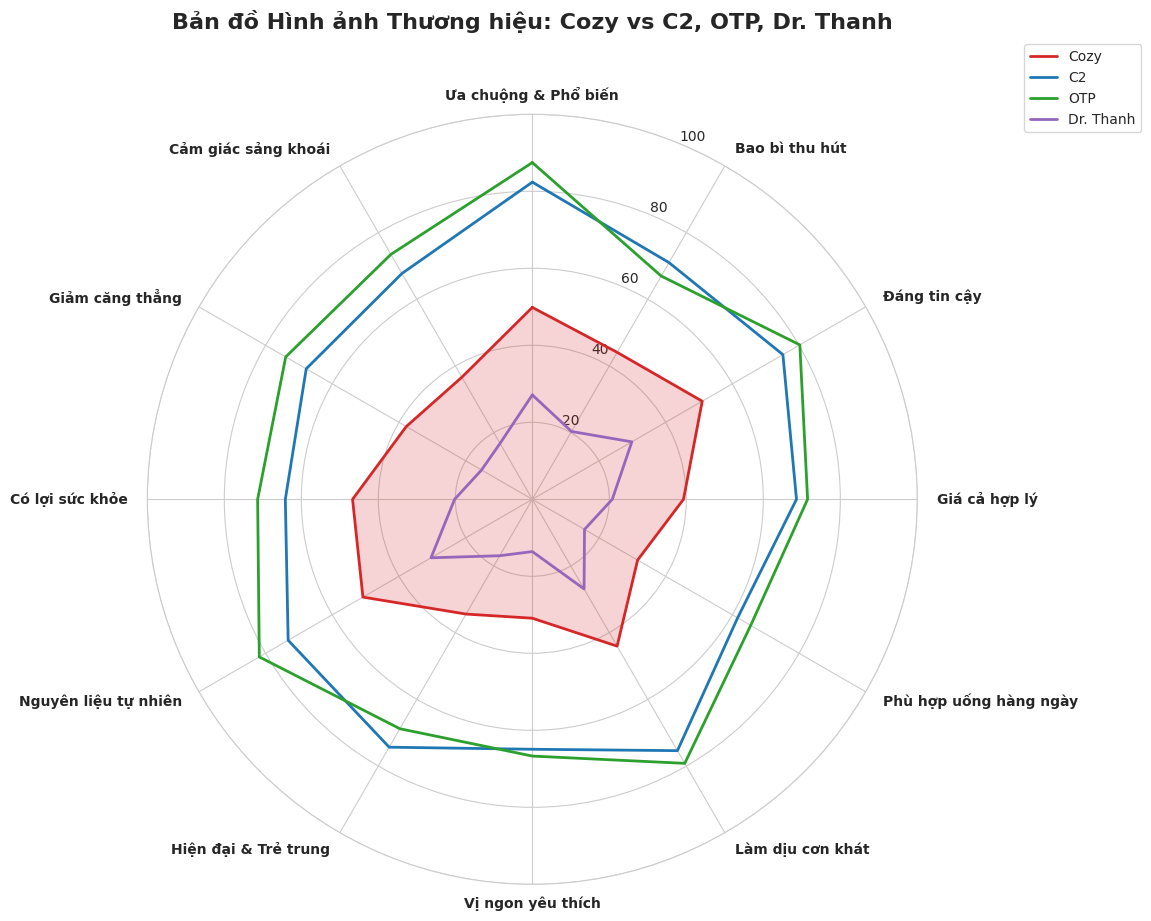

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Danh sách 4 thương hiệu theo yêu cầu mới
target_brands = ['Trà Cozy đóng chai', 'C2', 'OLong Tea Plus', 'Dr. Thanh']
labels = [
    'Ưa chuộng & Phổ biến', 'Bao bì thu hút', 'Đáng tin cậy',
    'Giá cả hợp lý', 'Phù hợp uống hàng ngày', 'Làm dịu cơn khát',
    'Vị ngon yêu thích', 'Hiện đại & Trẻ trung', 'Nguyên liệu tự nhiên',
    'Có lợi sức khỏe', 'Giảm căng thẳng', 'Cảm giác sảng khoái'
]

# Ánh xạ tới các cột tương ứng trong DataFrame
attr_cols = [
    'Những thương hiệu được ưa chuộng và phổ biến',
    'Bao bì có thiết kế thu hút',
    'Nhãn hiệu đáng tin cậy',
    'Giá cả hợp lý với chất lượng mang lại',
    'Phù hợp để thưởng thức hàng ngày',
    'Làm dịu cơn khát',
    'Vị ngon mà tôi yêu thích',
    'Thương hiệu mang tính hiện đại, trẻ trung',
    'Sản xuất từ nguyên liệu tự nhiên',
    'Có lợi cho sức khỏe',
    'Giúp giảm căng thẳng và mệt mỏi',
    'Tạo cảm giác sảng khoái'
]

brand_data = {}
for b in target_brands:
    scores = []
    for attr in attr_cols:
        col = f'QI - {b}_{attr}'
        if col in df.columns:
            scores.append(df[col].eq('Yes').mean() * 100)
        else:
            scores.append(0)
    brand_label = b.replace('Trà Cozy đóng chai', 'Cozy').replace('OLong Tea Plus', 'OTP')
    brand_data[brand_label] = scores

# 2. Vẽ biểu đồ Radar
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
# Bảng màu phân biệt rõ 4 brand
colors = {'Cozy': '#d62728', 'C2': '#1f77b4', 'OTP': '#2ca02c', 'Dr. Thanh': '#9467bd'}

for brand_name, scores in brand_data.items():
    data = scores + scores[:1]
    ax.plot(angles, data, color=colors.get(brand_name, '#888'), linewidth=2, label=brand_name)
    if brand_name == 'Cozy':
        ax.fill(angles, data, color=colors[brand_name], alpha=0.2)

# Định dạng
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10, fontweight='bold')

# Căn chỉnh nhãn
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle == 0 or angle == np.pi: label.set_horizontalalignment('center')
    elif 0 < angle < np.pi: label.set_horizontalalignment('left')
    else: label.set_horizontalalignment('right')

ax.set_ylim(0, 100)
plt.title('Bản đồ Hình ảnh Thương hiệu: Cozy vs C2, OTP, Dr. Thanh', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### Phân tích Media Touchpoints: Cozy vs Đối thủ
Biểu đồ này so sánh tỷ lệ tiếp cận của người tiêu dùng đối với các hoạt động truyền thông và quảng cáo của Cozy so với các đối thủ dẫn đầu thị trường.

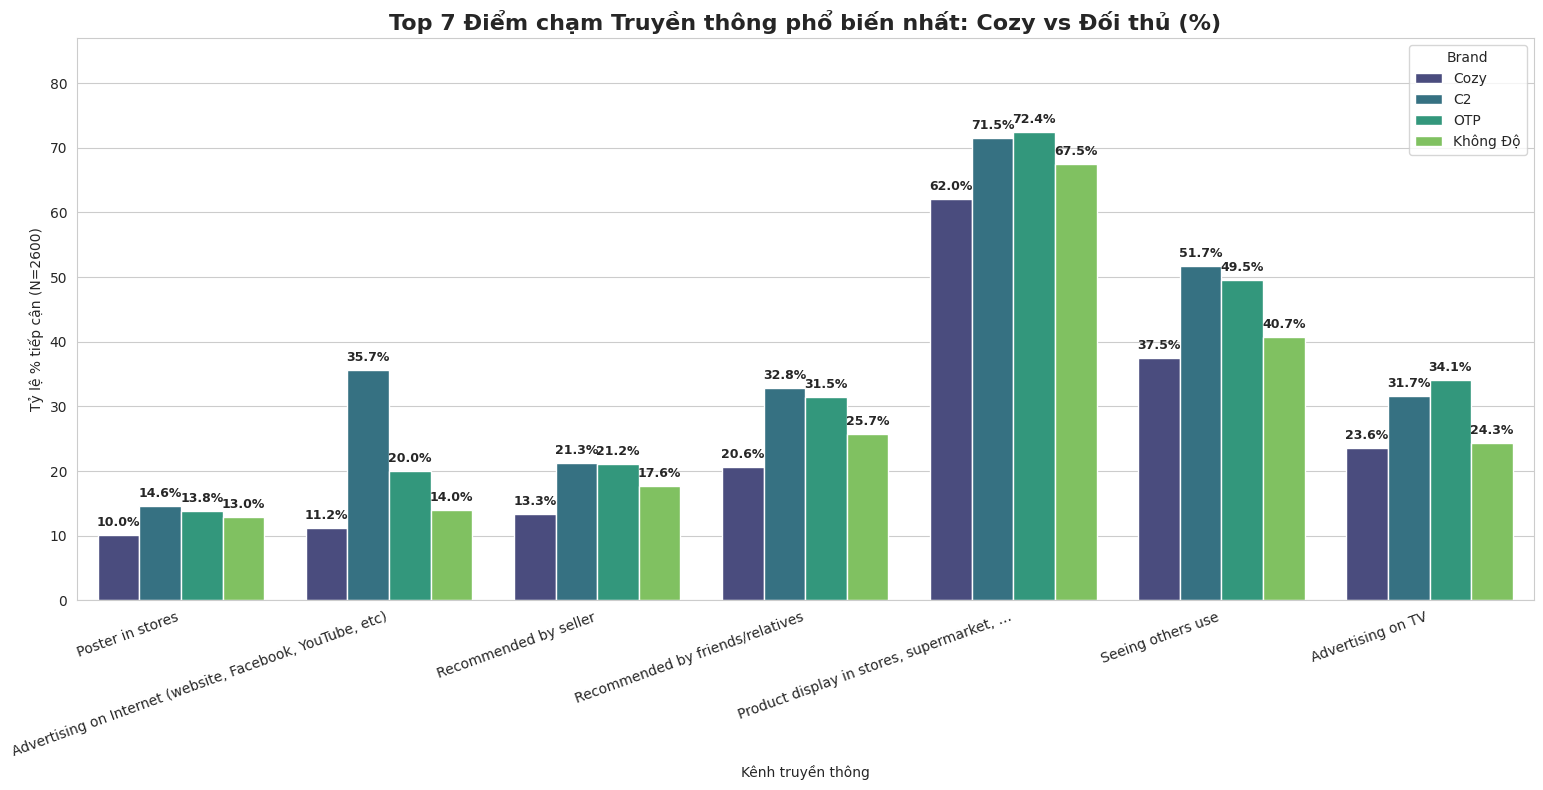

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa các brands và mapping nhãn
target_brands = {
    'Trà Cozy đóng chai': 'Cozy',
    'C2': 'C2',
    'OLong Tea Plus': 'OTP',
    'Không Độ': 'Không Độ'
}

# 2. Tìm tất cả các loại touchpoints có trong dữ liệu (Q_TP1)
tp_cols_all = [c for c in df.columns if 'Q_TP1' in c]
tp_types = set()
for col in tp_cols_all:
    # Lấy phần tên touchpoint (thường sau dấu gạch dưới cuối cùng)
    parts = col.split('_')
    if len(parts) > 1:
        tp_types.add(parts[-1].strip())

TOTAL_N = 2600
tp_stats = []

# 3. Tính toán tỷ lệ cho từng brand và từng loại touchpoint
for full_brand, short_brand in target_brands.items():
    for tp in tp_types:
        relevant_cols = [c for c in df.columns if 'Q_TP1' in c and full_brand in c and tp in c]
        if relevant_cols:
            count = df[relevant_cols].apply(lambda x: x.astype(str).str.strip().str.lower().isin(['1', 'yes', 'selected', 'checked']).any(), axis=1).sum()
            tp_stats.append({
                'Brand': short_brand,
                'Touchpoint': tp,
                'Percentage': (count / TOTAL_N) * 100
            })

tp_full_df = pd.DataFrame(tp_stats)

# 4. Tìm Top 7 Touchpoints phổ biến nhất (dựa trên trung bình các brand)
top_7_tp = tp_full_df.groupby('Touchpoint')['Percentage'].mean().nlargest(7).index.tolist()
plot_df = tp_full_df[tp_full_df['Touchpoint'].isin(top_7_tp)]

# 5. Trực quan hóa
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_df, x='Touchpoint', y='Percentage', hue='Brand', palette='viridis')

plt.title('Top 7 Điểm chạm Truyền thông phổ biến nhất: Cozy vs Đối thủ (%)', fontsize=16, fontweight='bold')
plt.ylabel('Tỷ lệ % tiếp cận (N=2600)')
plt.xlabel('Kênh truyền thông')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, plot_df['Percentage'].max() * 1.2)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Phân tích Điểm mua hàng (Purchase Touchpoints): Top 5 Phổ biến
Biểu đồ này tập trung vào các hoạt động tại điểm bán như trưng bày, khuyến mãi và tư vấn của người bán cho 4 thương hiệu chính.

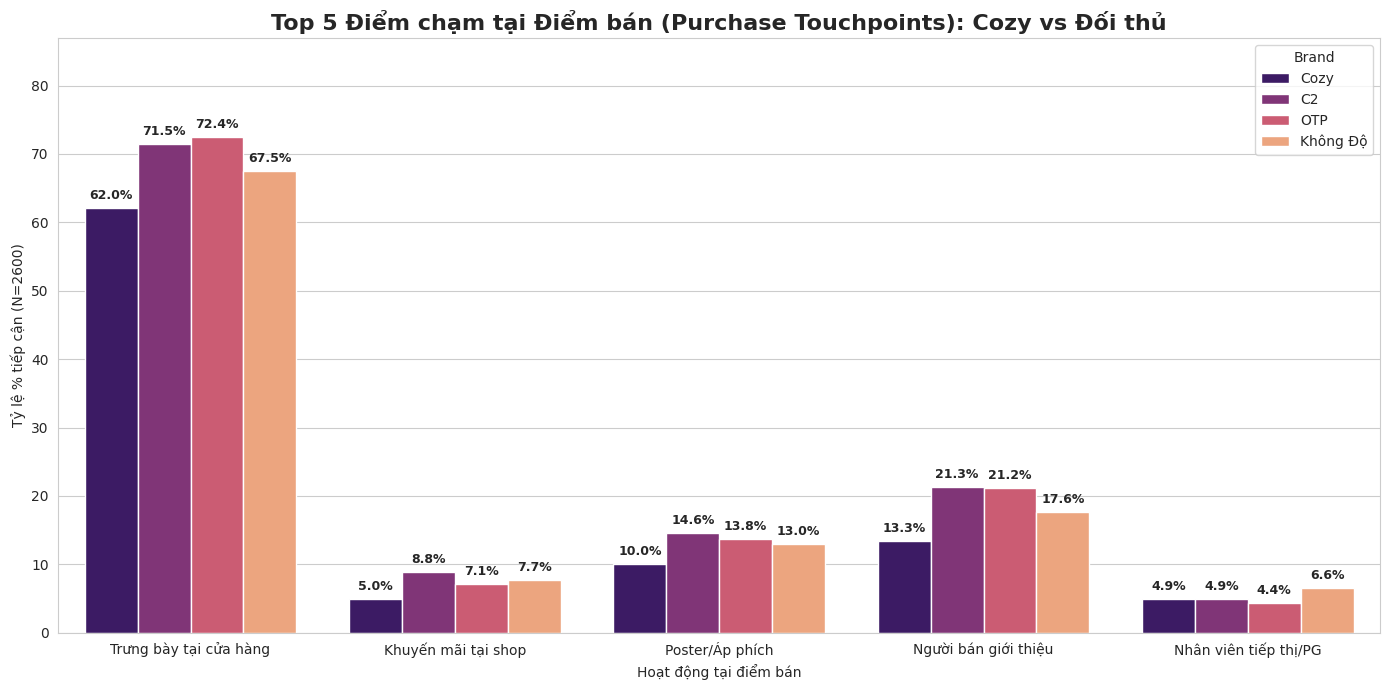

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa các touchpoints liên quan đến điểm mua hàng (Point of Purchase)
pop_touchpoints = {
    'Product display in stores, supermarket, …': 'Trưng bày tại cửa hàng',
    'Promotion in stores, supermarket, …': 'Khuyến mãi tại shop',
    'Poster in stores': 'Poster/Áp phích',
    'Recommended by seller': 'Người bán giới thiệu',
    'Marketing staff/ PG': 'Nhân viên tiếp thị/PG'
}

target_brands = {
    'Trà Cozy đóng chai': 'Cozy',
    'C2': 'C2',
    'OLong Tea Plus': 'OTP',
    'Không Độ': 'Không Độ'
}

TOTAL_N = 2600
pop_data = []

# 2. Tính toán dữ liệu
for full_brand, short_brand in target_brands.items():
    for tp_key, tp_label in pop_touchpoints.items():
        cols = [c for c in df.columns if 'Q_TP1' in c and full_brand in c and tp_key in c]
        if cols:
            count = df[cols].apply(lambda x: x.astype(str).str.strip().str.lower().isin(['1', 'yes', 'selected', 'checked']).any(), axis=1).sum()
            pop_data.append({
                'Brand': short_brand,
                'Touchpoint': tp_label,
                'Percentage': (count / TOTAL_N) * 100
            })

pop_df = pd.DataFrame(pop_data)

# 3. Trực quan hóa
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(data=pop_df, x='Touchpoint', y='Percentage', hue='Brand', palette='magma')

plt.title('Top 5 Điểm chạm tại Điểm bán (Purchase Touchpoints): Cozy vs Đối thủ', fontsize=16, fontweight='bold')
plt.ylabel('Tỷ lệ % tiếp cận (N=2600)')
plt.xlabel('Hoạt động tại điểm bán')
plt.ylim(0, pop_df['Percentage'].max() * 1.2)

# Thêm nhãn số liệu
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [118]:
import pandas as pd

# Exhaustive search for any column related to retail channels or purchase locations
# Using both English and Vietnamese terms common in market research datasets
search_terms = [
    'channel', 'outlet', 'where', 'buy', 'purchase', 'place',
    'kênh', 'nơi mua', 'mua ở đâu', 'siêu thị', 'cvs', 'tạp hóa',
    'market', 'store', 'shop', 'modern', 'traditional'
]

# Find all columns that match any search term
matching_columns = [col for col in df.columns if any(term in col.lower() for term in search_terms)]

print(f"Found {len(matching_columns)} matching columns.")

# Group findings by prefix to identify blocks of data (e.g., all Q11 columns)
if matching_columns:
    prefixes = sorted(list(set([col.split('.')[0] for col in matching_columns if '.' in col])))
    print(f"Common column prefixes found: {prefixes[:10]}")

    # Display details for the first 40 matches to identify the right block
    print("\nDetailed Column Inspection:")
    for col in matching_columns[:40]:
        # Get non-null unique values to understand data format
        samples = df[col].dropna().unique()[:5]
        print(f"- {col} | Values: {list(samples)}")
else:
    print("No matches found. Listing a slice of all column names for manual inspection:")
    print(df.columns[100:200].tolist())

Found 121 matching columns.
Common column prefixes found: ['QME2 - Dr', 'Q_TP1_C10_R19- Dr', 'Q_TP1_C11_R19- Dr', 'Q_TP1_C12_R19- Dr', 'Q_TP1_C8_R19- Dr', 'Q_TP1_C9_R19- Dr', 'S2']

Detailed Column Inspection:
- S2.Category used in P4W_Traditional drink (unbranded) | Values: ['No', 'Yes']
- QME2 - C2_Do not want other people see when I drink/buy this brand | Values: ['No', 'Yes']
- QME2 - C2_Asked but the store does not sell it | Values: ['No', 'Yes']
- QME2 - C2_Not preserved in cool place | Values: ['No', 'Yes']
- QME2 - OLong Tea Plus_Do not want other people see when I drink/buy this brand | Values: ['No', 'Yes']
- QME2 - OLong Tea Plus_Asked but the store does not sell it | Values: ['No', 'Yes']
- QME2 - OLong Tea Plus_Not preserved in cool place | Values: ['No', 'Yes']
- QME2 - Không Độ_Do not want other people see when I drink/buy this brand | Values: ['No', 'Yes']
- QME2 - Không Độ_Asked but the store does not sell it | Values: ['Yes', 'No']
- QME2 - Không Độ_Not preserved in c

In [119]:
# Searching for specific retail brands or common channel naming conventions
retail_keywords = ['winmart', 'circle k', '7-eleven', 'gs25', 'family mart', 'coop', 'bách hóa xanh', 'lotte', 'go!', 'aeon']

# Check for these terms in column names
found_retail_cols = [col for col in df.columns if any(kw in col.lower() for kw in retail_keywords)]

print(f"Found {len(found_retail_cols)} columns matching retail names.")
if found_retail_cols:
    for col in found_retail_cols[:20]:
        samples = df[col].dropna().unique()[:3]
        print(f"- {col} | Samples: {list(samples)}")
else:
    # If still not found, search for the Q-series that typically follows brand usage (Q5-Q10)
    q_search = [col for col in df.columns if any(col.startswith(p) for p in ['Q7', 'Q8', 'Q9', 'Q10'])]
    print(f"Falling back to Q7-Q10 prefixes. Found {len(q_search)} columns.")
    for col in q_search[:20]:
        samples = df[col].dropna().unique()[:3]
        print(f"- {col} | Samples: {list(samples)}")

Found 0 columns matching retail names.
Falling back to Q7-Q10 prefixes. Found 1 columns.
- Q7. Previous BUMO | Samples: ['OLong Tea Plus', 'Không Độ', 'Trà Tea Go']


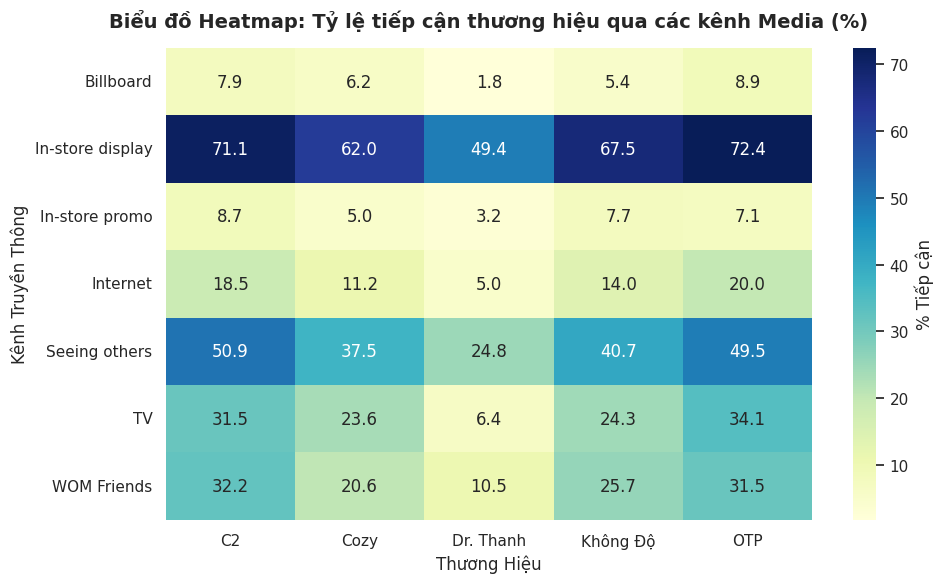

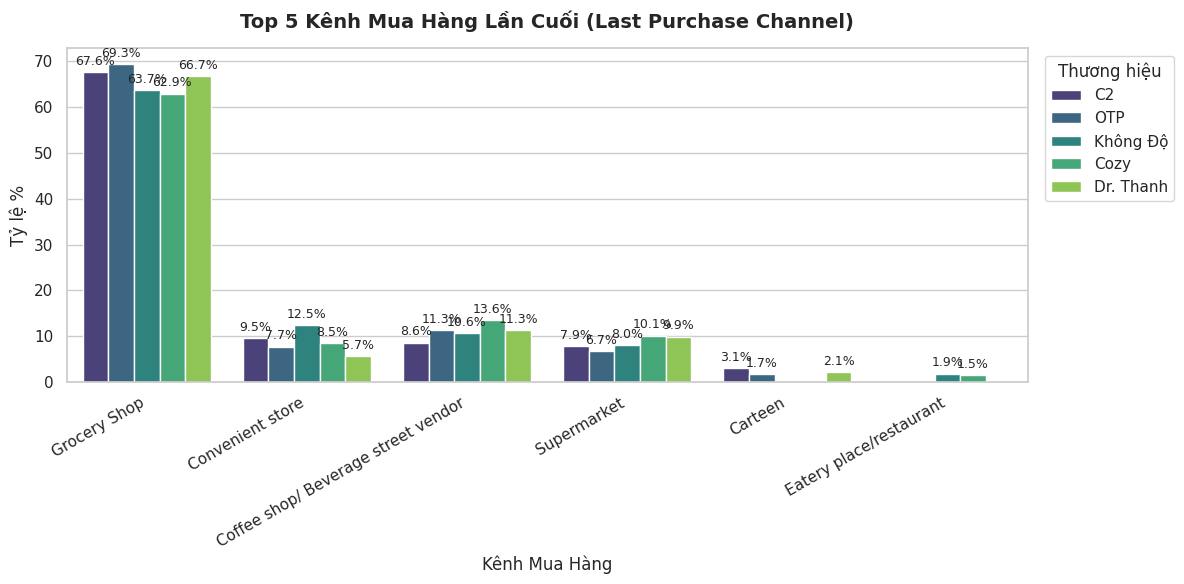

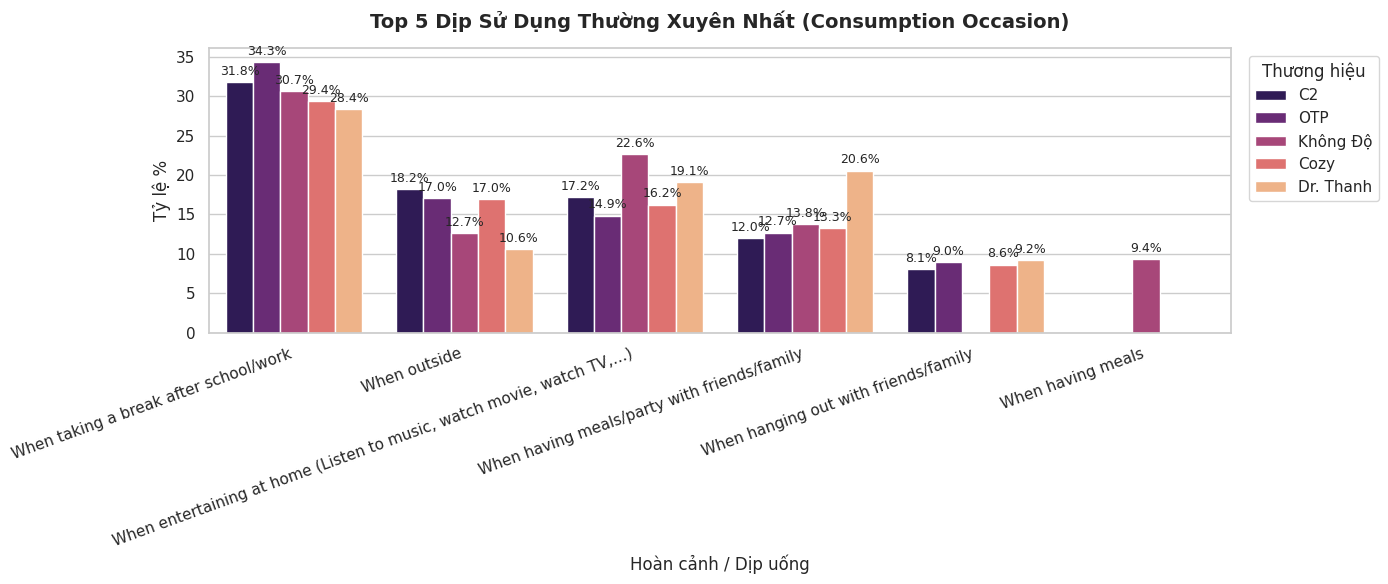

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_excel("/content/myInsight 2026_V2_Dataset.xlsx", sheet_name='Dataset')

brands5 = ['C2', 'Không Độ', 'Trà Cozy đóng chai', 'Dr. Thanh', 'OLong Tea Plus']
media_map = {
    'C2': 'R1', 'OLong Tea Plus': 'R7', 'Không Độ': 'R11',
    'Trà Cozy đóng chai': 'R15', 'Dr. Thanh': 'R19'
}
channels = {
    'TV': 'C1', 'Internet': 'C2', 'Billboard': 'C4',
    'In-store display': 'C8', 'In-store promo': 'C11',
    'WOM Friends': 'C14', 'Seeing others': 'C15',
}

# ==========================================
# 1. MEDIA TOUCHPOINT (Kênh Truyền Thông)
# ==========================================
media_data = []

for ch_name, ch_code in channels.items():
    for b in brands5:
        short = b.replace('Trà Cozy đóng chai','Cozy').replace('OLong Tea Plus','OTP')
        r_code = media_map.get(b,'')
        matching = [c for c in df.columns if c.startswith(f'Q_TP1_{ch_code}_{r_code}-')]

        pct = 0
        if matching:
            pct = df[matching[0]].eq('Yes').mean() * 100

        media_data.append({'Channel': ch_name, 'Brand': short, 'Percentage': pct})

df_media = pd.DataFrame(media_data)
df_media_pivot = df_media.pivot(index="Channel", columns="Brand", values="Percentage")

# Vẽ biểu đồ Heatmap cho Media
plt.figure(figsize=(10, 6))
sns.heatmap(df_media_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% Tiếp cận'})
plt.title("Biểu đồ Heatmap: Tỷ lệ tiếp cận thương hiệu qua các kênh Media (%)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Kênh Truyền Thông")
plt.xlabel("Thương Hiệu")
plt.tight_layout()
plt.show()

# ==========================================
# 2. PURCHASE CHANNEL (Kênh Mua Hàng)
# ==========================================
tp2_brands = {'C2':'R1','OLong Tea Plus':'R7','Không Độ':'R11','Trà Cozy đóng chai':'R15','Dr. Thanh':'R19'}
purchase_data = []

for b, code in tp2_brands.items():
    col = f'Q_TP2_{code}- {b}'
    if col in df.columns:
        vc = df[col].value_counts(normalize=True).head(5) * 100
        short = b.replace('Trà Cozy đóng chai','Cozy').replace('OLong Tea Plus','OTP')
        for k, v in vc.items():
            purchase_data.append({'Brand': short, 'Purchase Channel': k, 'Percentage': v})

df_purchase = pd.DataFrame(purchase_data)

# Vẽ biểu đồ Cột cho Kênh Mua Hàng
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_purchase, x='Purchase Channel', y='Percentage', hue='Brand', palette='viridis')
plt.title("Top 5 Kênh Mua Hàng Lần Cuối (Last Purchase Channel)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Tỷ lệ %")
plt.xlabel("Kênh Mua Hàng")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Thương hiệu', bbox_to_anchor=(1.01, 1), loc='upper left')

# Thêm số liệu trên đầu cột
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

# ==========================================
# 3. CONSUMPTION OCCASION (Dịp Sử Dụng)
# ==========================================
occasion_data = []

for b, code in tp2_brands.items():
    col = f'Q_TP3_{code}- {b}'
    if col in df.columns:
        vc = df[col].value_counts(normalize=True).head(5) * 100
        short = b.replace('Trà Cozy đóng chai','Cozy').replace('OLong Tea Plus','OTP')
        for k, v in vc.items():
            occasion_data.append({'Brand': short, 'Occasion': k, 'Percentage': v})

df_occasion = pd.DataFrame(occasion_data)

# Vẽ biểu đồ Cột cho Dịp Sử Dụng
plt.figure(figsize=(14, 6))
ax2 = sns.barplot(data=df_occasion, x='Occasion', y='Percentage', hue='Brand', palette='magma')
plt.title("Top 5 Dịp Sử Dụng Thường Xuyên Nhất (Consumption Occasion)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Tỷ lệ %")
plt.xlabel("Hoàn cảnh / Dịp uống")
plt.xticks(rotation=20, ha='right')
plt.legend(title='Thương hiệu', bbox_to_anchor=(1.01, 1), loc='upper left')

# Thêm số liệu trên đầu cột
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

### Phân tích Phân phối theo Kênh (Retail Channel Distribution)
Sau khi xác định được các cột về địa điểm mua hàng, chúng ta sẽ thống kê tỷ lệ hiện diện của Cozy tại các kênh trọng điểm của Gen Z.

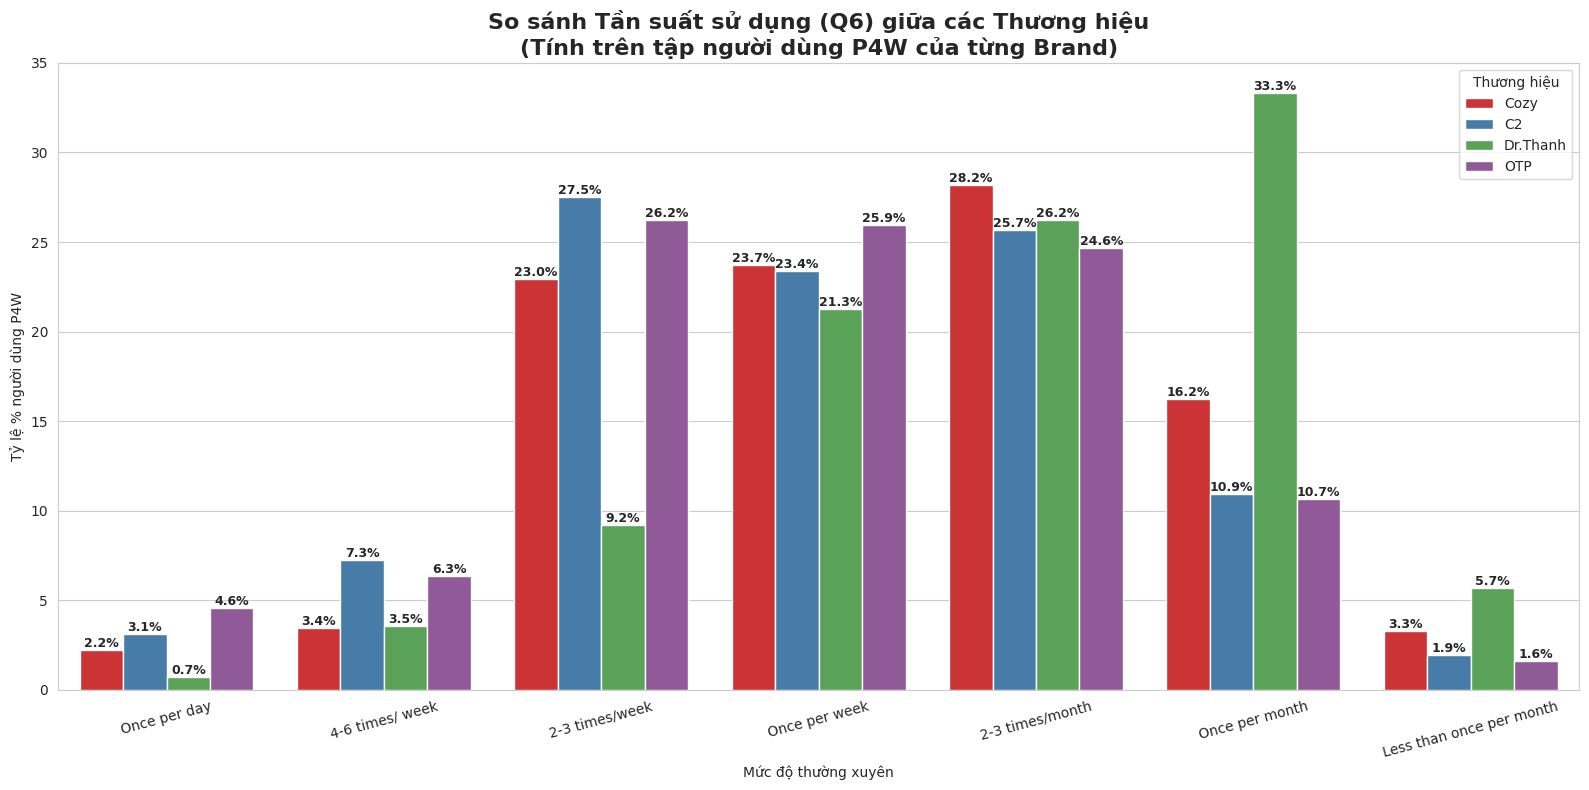

Brand,C2,Cozy,Dr.Thanh,OTP
Tần suất,,,,
Once per day,3.133333,2.235469,0.709220,4.558405
4-6 times/ week,7.266667,3.427720,3.546099,6.339031
2-3 times/week,27.533333,22.950820,9.219858,26.210826
Once per week,23.400000,23.695976,21.276596,25.925926
2-3 times/month,25.666667,28.166915,26.241135,24.643875
Once per month,10.933333,16.244411,33.333333,10.683761
Less than once per month,1.933333,3.278689,5.673759,1.638177


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def check_selected(val):
    s = str(val).strip().lower()
    return s in ['1', 'yes', 'selected', 'checked', '1.0']

# 1. Định nghĩa các thương hiệu và từ khóa để tìm cột động
brands_map = {
    'Cozy': 'Cozy',
    'C2': 'C2',
    'Dr.Thanh': 'Dr. Thanh',
    'OTP': 'OLong Tea Plus'
}

all_freq_data = []

# 2. Xử lý dữ liệu cho từng brand
for nick, kw in brands_map.items():
    p4w_cols = [c for c in df.columns if 'Q4. P4W' in c and kw.lower() in c.lower()]
    q6_cols = [c for c in df.columns if 'Q6' in c and kw.lower() in c.lower()]

    if p4w_cols and q6_cols:
        p4w_mask = df[p4w_cols].apply(lambda row: row.apply(check_selected).any(), axis=1)
        brand_p4w_df = df[p4w_mask].copy()

        n_size = len(brand_p4w_df)
        if n_size > 0:
            freq_stats = brand_p4w_df[q6_cols[0]].value_counts().reset_index()
            freq_stats.columns = ['Tần suất', 'Số lượng']
            freq_stats['Tỷ lệ (%)'] = (freq_stats['Số lượng'] / n_size) * 100
            freq_stats['Brand'] = nick
            all_freq_data.append(freq_stats)

if not all_freq_data:
    print("Không tìm thấy dữ liệu phù hợp.")
else:
    # Reset index để tránh lỗi duplicate labels khi plotting
    plot_df = pd.concat(all_freq_data).reset_index(drop=True)

    # 3. Vẽ biểu đồ cột đứng
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")

    freq_order = ['Once per day', '4-6 times/ week', '2-3 times/week', 'Once per week', '2-3 times/month', 'Once per month', 'Less than once per month']

    ax = sns.barplot(x='Tần suất', y='Tỷ lệ (%)', hue='Brand', data=plot_df, order=freq_order, palette='Set1')

    plt.title('So sánh Tần suất sử dụng (Q6) giữa các Thương hiệu\n(Tính trên tập người dùng P4W của từng Brand)', fontsize=16, fontweight='bold')
    plt.ylabel('Tỷ lệ % người dùng P4W')
    plt.xlabel('Mức độ thường xuyên')
    plt.xticks(rotation=15)
    plt.legend(title='Thương hiệu', loc='upper right')

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Display summary table
    final_pivot = plot_df.pivot_table(index='Tần suất', columns='Brand', values='Tỷ lệ (%)').reindex(freq_order)
    display(final_pivot)